# CardioRisk Prediction

## Problem Statement

CardioCare, a healthcare provider, is committed to enhancing preventative care and improving patient outcomes. With the growing prevalence of cardiovascular disease (CVD), accurate and timely risk assessment is essential. Although CardioCare might provide comprehensive medical resources, optimising doctors' valuable consultation time is crucial for efficient and effective care. At the same time, correctly identifying at-risk patients is highly important.

### Business Objective

CardioCare aims to develop a machine learning model to predict CVD risk using patient health data. This model is intended to support healthcare providers in efficiently allocating resources and optimising doctors' consultation time. By identifying patients with high risk of CVD, the model can help prioritise consultations and potentially eliminate the need for an initial consultation stage for some patients. This will allow doctors to focus their expertise on individuals requiring immediate attention.

### Assignment Tasks

You need to perform the following steps to complete this assignment:
1. Data Understanding
2. Data Cleaning
3. Exploratory Data Analysis
4. Train Validation Split
5. Feature Engineering
6. Model Building
8. Prediction and Model Evaluation

**Based on this assignment, you have to answer the following questions:**

- What insights can we gain from exploring the relationships between different health metrics and the prevalence of cardiovascular disease within the patient population?

- Based on the analysis, which patient characteristics emerge as the strongest predictors of cardiovascular disease risk? Are there any surprising or unexpected findings?

- How effectively can machine learning models identify individuals at risk of developing cardiovascular disease based on their health data? How does the evaluation results vary across different models?

- How can CardioCare integrate the predictive model into their existing healthcare workflows to enhance preventative care strategies?

### Data Dictionary

The CardioRisk Prediction has 14 Columns and 70000 Rows. Following data dictionary provides the description for each column present in dataset:


<table>
  <tr>
    <th>Column Name</th>
    <th>Description</th>
  </tr>
  <tr>
    <td>Unnamed: 0</td>
    <td>Index or row number</td>
  </tr>
  <tr>
    <td>id</td>
    <td>Unique identifier for each individual in the dataset</td>
  </tr>
  <tr>
    <td>age</td>
    <td>Age of the individual, measured in days</td>
  </tr>
  <tr>
    <td>gender</td>
    <td>Gender of the individual (1: Female, 2: Male)</td>
  </tr>
  <tr>
    <td>height</td>
    <td>Height of the individual, measured in centimeters</td>
  </tr>
  <tr>
    <td>weight</td>
    <td>Weight of the individual, measured in kilograms</td>
  </tr>
  <tr>
    <td>ap_hi</td>
    <td>Systolic blood pressure reading</td>
  </tr>
  <tr>
    <td>ap_lo</td>
    <td>Diastolic blood pressure reading</td>
  </tr>
  <tr>
    <td>cholesterol</td>
    <td>Cholesterol level (1: normal, 2: above normal, 3: well above normal)</td>
  </tr>
  <tr>
    <td>gluc</td>
    <td>Glucose level (1: normal, 2: above normal, 3: well above normal)</td>
  </tr>
  <tr>
    <td>smoke</td>
    <td>Smoking status (0: No, 1: Yes)</td>
  </tr>
  <tr>
    <td>alco</td>
    <td>Alcohol intake status (0: No, 1: Yes)</td>
  </tr>
  <tr>
    <td>active</td>
    <td>Physical activity status (0: No, 1: Yes)</td>
  </tr>
  <tr>
    <td>cardio</td>
    <td>Presence or absence of cardiovascular disease (0: No Disease, 1: Disease)</td>
  </tr>
</table>

</body>
</html>


    
This data dictionary serves as a reference for understanding the dataset and its variables.

## **1. Data Understanding**

<font color = red>[2 marks]</font> <br>

In this stage, you have to load the dataset and check basic statistics of the data, including preview of data, dimension of data, column descriptions and data types.

In [1]:
# suggested imports; import more libraries as needed
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, precision_recall_curve, \
    confusion_matrix, classification_report, roc_curve, roc_auc_score
from sklearn.model_selection import train_test_split, GridSearchCV
import warnings
warnings.filterwarnings('ignore')

### **1.1 Load the dataset**

<font color = red>[2 marks]</font> <br>


# Load the dataset


In [2]:
df = pd.read_csv('/content/health_data.csv')

#### **1.1.1** Check the first few entries

In [3]:
# Check the first few entries
display(df.head())

,Unnamed: 0,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,0.0,18393.0,1,168.0,62.0,110.0,80.0,0,0,0,0,1,0
1,1,1.0,20228.0,0,156.0,85.0,140.0,90.0,2,0,0,0,1,1
2,2,2.0,18857.0,0,165.0,64.0,130.0,70.0,2,0,0,0,0,1
3,3,3.0,17623.0,1,169.0,82.0,150.0,100.0,0,0,0,0,1,1
4,4,4.0,17474.0,0,156.0,56.0,100.0,60.0,0,0,0,0,0,0


#### **1.1.2** Remove columns which are irrelevant <font color = red>[2 marks]</font> <br>

In [5]:
# Remove irrelevant columns like unique identifiers or index
df = df.drop(columns=['Unnamed: 0', 'id'])

#unnamed and id being dropped as they are unique identifiers and don't contribute to the prediction.

KeyError: "['Unnamed: 0', 'id'] not found in axis"

#### **1.1.3** Inspect the shape of the dataset

In [6]:
# Inspect the shape of the dataset
display(df.shape)

(70000, 12)

#### **1.1.4** Inspect the different columns in the dataset

In [7]:
# Inspect the different columns in the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          70000 non-null  float64
 1   gender       70000 non-null  int64  
 2   height       70000 non-null  float64
 3   weight       70000 non-null  float64
 4   ap_hi        70000 non-null  float64
 5   ap_lo        70000 non-null  float64
 6   cholesterol  70000 non-null  int64  
 7   gluc         70000 non-null  int64  
 8   smoke        70000 non-null  int64  
 9   alco         70000 non-null  int64  
 10  active       70000 non-null  int64  
 11  cardio       70000 non-null  int64  
dtypes: float64(5), int64(7)
memory usage: 6.4 MB


Check the summary of the dataset

In [8]:
# Check the summary of the dataset
#short statistical summary of the dataset's numerical columns.

display(df.describe())

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,19468.865814,0.349571,164.359229,74.205690,128.817286,96.630414,0.366871,0.226457,0.088129,0.053771,0.803729,0.499700
std,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,10798.000000,0.000000,55.000000,10.000000,-150.000000,-70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17664.000000,0.000000,159.000000,65.000000,120.000000,80.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,19703.000000,0.000000,165.000000,72.000000,120.000000,80.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,21327.000000,1.000000,170.000000,82.000000,140.000000,90.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,23713.000000,1.000000,250.000000,200.000000,16020.000000,11000.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000


## **2. Data Cleaning**

<font color = red>[8 marks]</font> <br>

### **2.1 Identify and handle redundant or invalid/illogical physiological values**

<font color = red>[6 marks]</font> <br>

Examine the dataset to identify any columns containing data points that are invalid, illogical, or fall outside of typical physiological ranges.

- Pay attention to blood pressure values and ensure they fall within reasonable physiological limits. Very high or low values might need to be investigated or addressed. Blood pressure values less than 30 and more than 300 are rarely observed.
- Additionally, think about which unit might be more intuitive for understanding a person's age in a healthcare context.
- Similarly, reflect on the representation of height and explore whether using a different unit would align better with typical practices in healthcare and enhance the overall interpretability of the data.

#### **2.1.1** Check the statistical summary of the data <font color = red>[1 marks]</font> <br>

Examine the statistical summary to identify the columns containing data points that are invalid, illogical, or fall outside of typical physiological ranges.

In [9]:
# Check the statistical summary of the data
display(df.describe())

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,19468.865814,0.349571,164.359229,74.205690,128.817286,96.630414,0.366871,0.226457,0.088129,0.053771,0.803729,0.499700
std,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,10798.000000,0.000000,55.000000,10.000000,-150.000000,-70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17664.000000,0.000000,159.000000,65.000000,120.000000,80.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,19703.000000,0.000000,165.000000,72.000000,120.000000,80.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,21327.000000,1.000000,170.000000,82.000000,140.000000,90.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,23713.000000,1.000000,250.000000,200.000000,16020.000000,11000.000000,2.000000,2.000000,1.000000,1.000000,1.000000,1.000000


#### **2.1.2** Handle rows with invalid/illogical values <font color = red>[3 marks]</font> <br>

Based on the details of data present in statistical summary, handle the columns that have invalid/illogical values or does not fall within physiological limits or have extreme values.

In [10]:
# Handle rows which have invalid or illogical values or does not fall within physiological limits (include extreme cases) for blood pressure and height etc

#examining the statistical summary (df.describe()), we find several observations regarding potential invalid, illogical, or out-of-range data points:

#age: Currently represented in days. Converting it to years would be more intuitive for healthcare context.
#height: The minimum height is 55 cm, which is extremely low for an adult, and the maximum is 250 cm, which is very high. Both might indicate outliers or data entry errors. Converting it to meters would also be more standard.
#weight: The minimum weight is 10 kg, which is exceptionally low for an adult. The maximum of 200 kg is very high, suggesting potential outliers.
#ap_hi (Systolic Blood Pressure): This column has a minimum value of -150, which is physiologically impossible. The maximum value of 16020 is also an extreme outlier or data entry error, far beyond any realistic blood pressure reading. These values are definitely invalid.
#ap_lo (Diastolic Blood Pressure): Similar to ap_hi, the maximum value of 11000 is physiologically impossible. The minimum is 0, which while rare, can occur, but values less than 30 (as mentioned in the problem description) are generally considered invalid. Also, diastolic pressure should always be less than systolic pressure.
#gender, cholesterol, gluc: The describe() output shows values for gender as 0/1 (instead of 1/2 as per data dictionary), and cholesterol/gluc as 0/1/2 (instead of 1/2/3). It seems these categorical features might have been re-encoded. Assuming 0, 1, 2 are the intended categories, these ranges are consistent. We should be mindful of this potential re-encoding if comparing directly to the original data dictionary definitions.

df_clean = df.copy()

# Filter out extreme values for ap_hi (systolic blood pressure)
# Based on physiological limits, ap_hi typically ranges from 70 to 200. Values outside this range are considered outliers.
# We will filter for ap_hi between 70 and 200, but allow up to 300 as stated in problem description
df_clean = df_clean[df_clean['ap_hi'].between(30, 300)]

# Filter out extreme values for ap_lo (diastolic blood pressure)
# Based on physiological limits, ap_lo typically ranges from 40 to 120. Values outside this range are considered outliers.
# We will filter for ap_lo between 30 and 200, but allow up to 200 as stated in problem description
df_clean = df_clean[df_clean['ap_lo'].between(30, 200)]

# Filter out cases where diastolic pressure is greater than or equal to systolic pressure
df_clean = df_clean[df_clean['ap_lo'] < df_clean['ap_hi']]

# Filter out illogical height values
# Considering typical adult height range, say 130 cm to 200 cm (55 inches to 79 inches)
# The problem description mentions 55cm to 250cm as extreme, so we'll use a slightly tighter range based on typical adult height.
df_clean = df_clean[df_clean['height'].between(130, 200)]

# Filter out illogical weight values
# Considering typical adult weight range, say 30 kg to 180 kg
df_clean = df_clean[df_clean['weight'].between(30, 180)]

# Display the shape of the cleaned DataFrame to see how many rows were removed
print(f"Original DataFrame shape: {df.shape}")
print(f"Cleaned DataFrame shape: {df_clean.shape}")

Original DataFrame shape: (70000, 12)
Cleaned DataFrame shape: (68580, 12)


#### **2.1.3** Modify the representation of patient age and height <font color = red>[2 marks]</font> <br>

In [11]:
# Modify the representation of patient age and height (to years and meters) for better understanding in a healthcare context

df_clean['age'] = (df_clean['age'] / 365.25).astype(int)
df_clean['height'] = df_clean['height'] / 100

print("Age converted to years and height converted to meters.")

Age converted to years and height converted to meters.


### **2.2 Fix DataTypes**

<font color = red>[2 marks]</font> <br>

#### **2.2.1** Review and fix the data types of all columns <font color = red>[2 marks]</font> <br>

Ensuring the columns accurately reflect the nature of the data

In [12]:
# Fix DataTypes of the categorical columns with incorrect DataTypes

print('Categorical columns:')
display(df_clean[['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']].head())


for col in ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']:
    df_clean[col] = df_clean[col].astype('category')



Categorical columns:


,gender,cholesterol,gluc,smoke,alco,active,cardio
0,1,0,0,0,0,1,0
1,0,2,0,0,0,1,1
2,0,2,0,0,0,0,1
3,1,0,0,0,0,1,1
4,0,0,0,0,0,0,0


In [13]:
# Check the final data types post conversion

print('Data types after converting categorical columns:')
df_clean.info()

Data types after converting categorical columns:
<class 'pandas.core.frame.DataFrame'>
Index: 68580 entries, 0 to 69999
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   age          68580 non-null  int64   
 1   gender       68580 non-null  category
 2   height       68580 non-null  float64 
 3   weight       68580 non-null  float64 
 4   ap_hi        68580 non-null  float64 
 5   ap_lo        68580 non-null  float64 
 6   cholesterol  68580 non-null  category
 7   gluc         68580 non-null  category
 8   smoke        68580 non-null  category
 9   alco         68580 non-null  category
 10  active       68580 non-null  category
 11  cardio       68580 non-null  category
dtypes: category(7), float64(4), int64(1)
memory usage: 3.6 MB


## **3. Exploratory Data Analysis**

<font color = red>[27 marks]</font>

### **3.1 Perform univariate analysis**

<font color = red>[12 marks]</font>

#### **3.1.1** Visualise the numerical features <font color = red>[5 marks]</font>

Visualise the distribution of numerical features using appropriate plots to understand their characteristics.

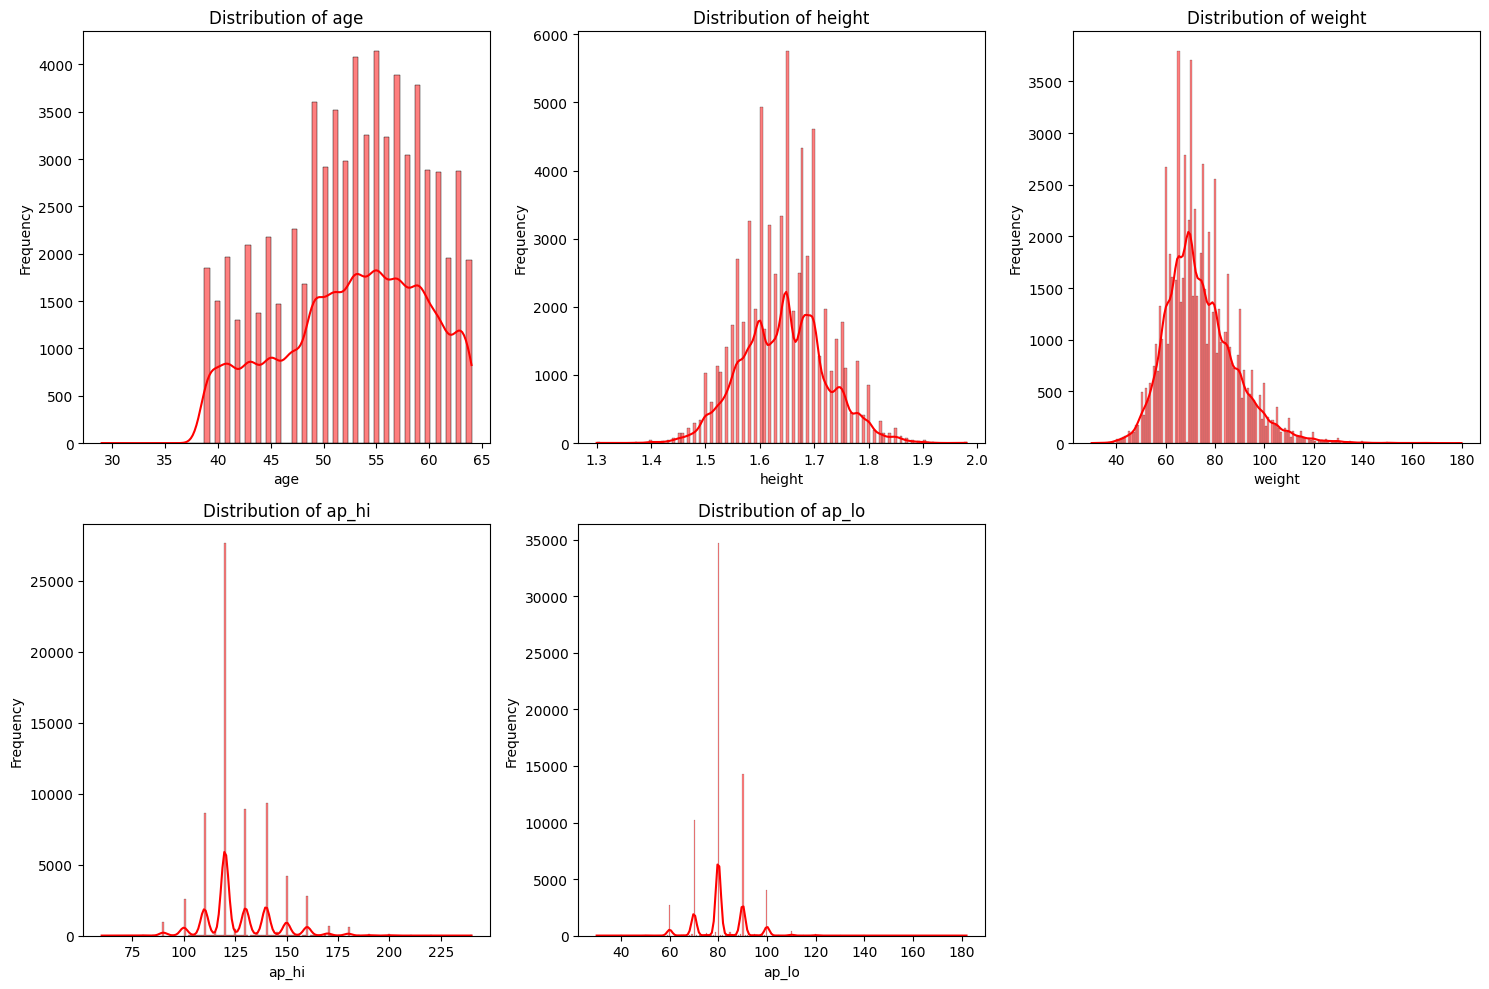

In [15]:
# Plot all the numerical columns to understand their distribution
#using histoplots to visualize the distribution of numerical features.
plt.figure(figsize=(15, 10))

# List of numerical columns to plot
numerical_cols = ['age', 'height', 'weight', 'ap_hi', 'ap_lo']

for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i + 1) # Arrange plots in 2 rows, 3 columns
    sns.histplot(df_clean[col], kde=True,color='red') # Use histplot for distribution and add KDE for density
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

#### **3.1.2** Visualise the categorical features <font color = red>[5 marks]</font>

Visualise the distribution of categorical features to get a clear view of the data distribution across various categories. This will help in identifying potential imbalances or dominant categories.

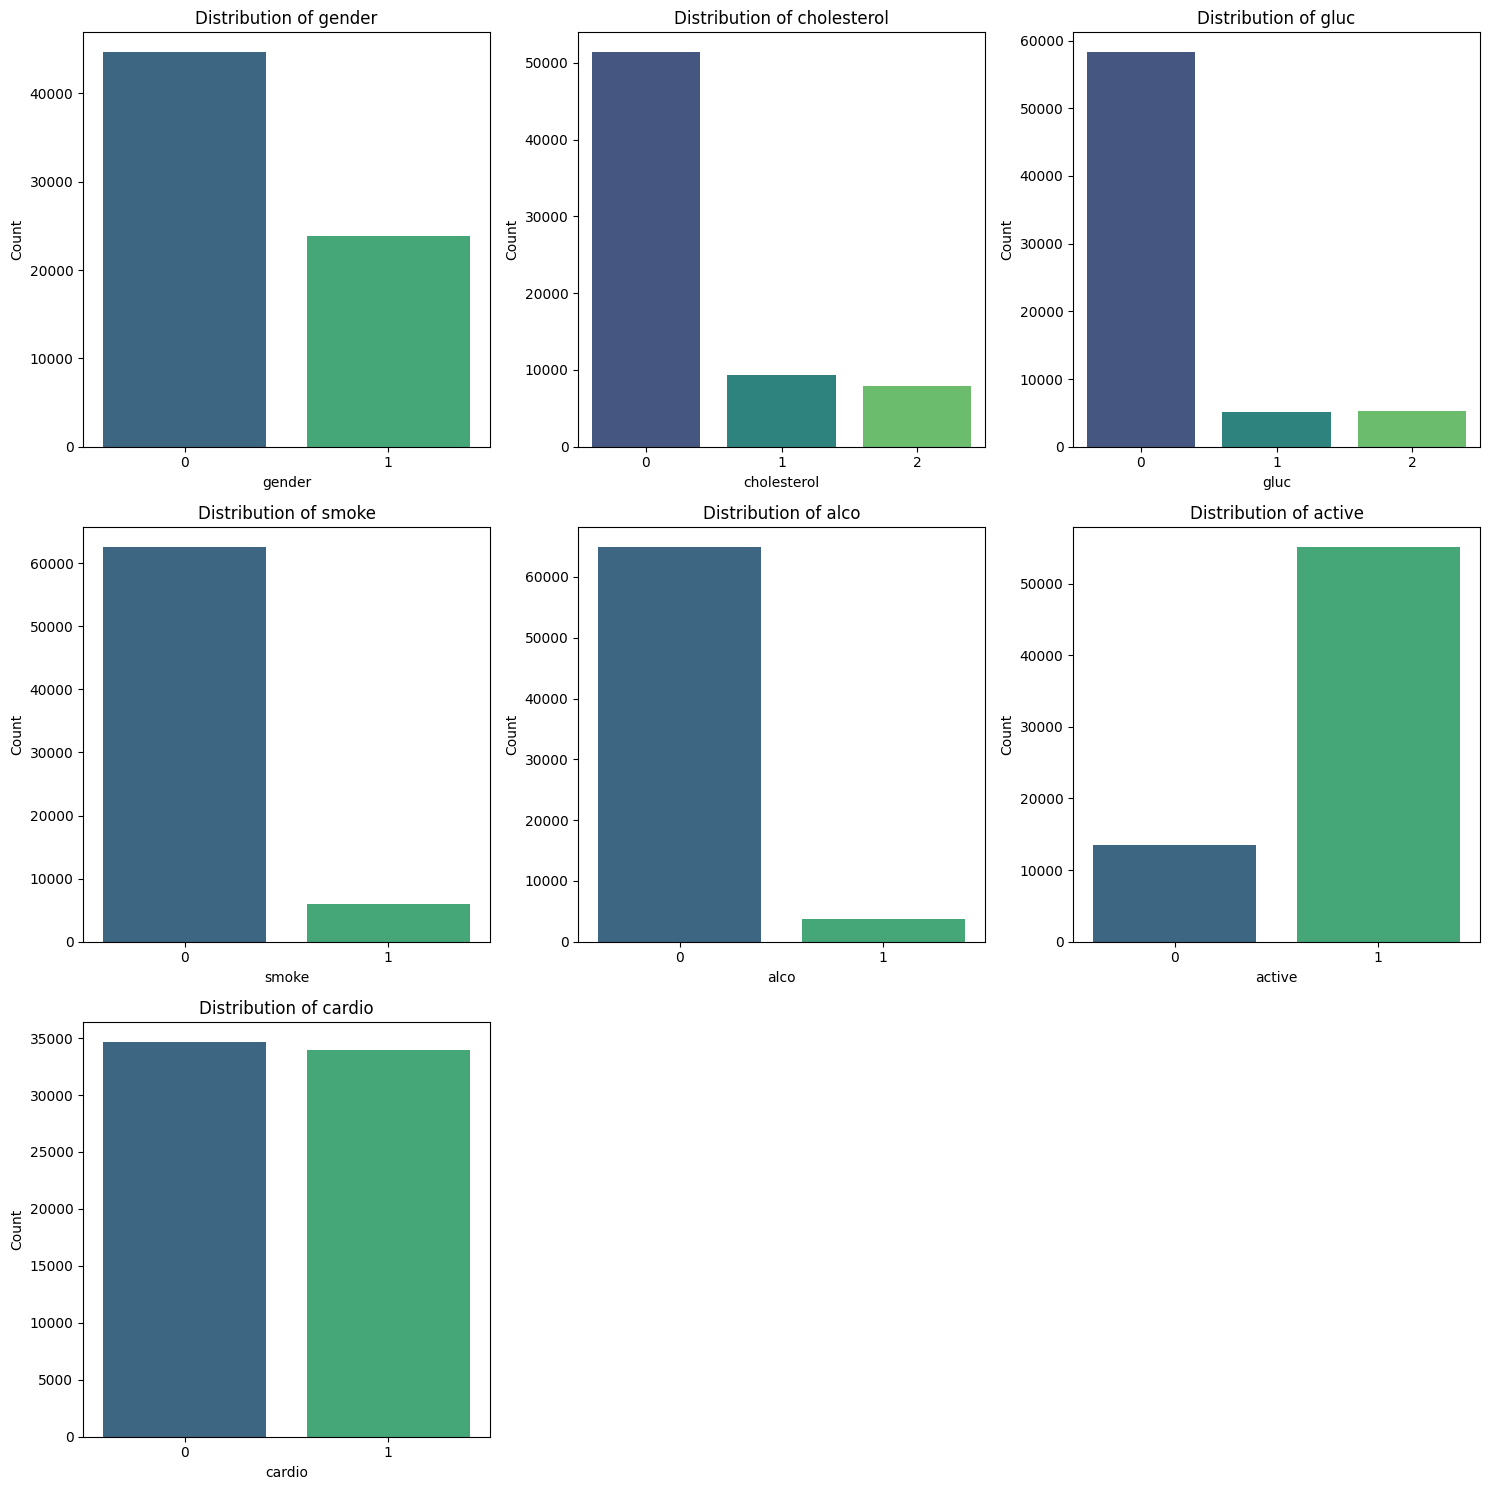

In [16]:
# Select and plot categorical columns
#count plots being used to show distribution of categorical values
categorical_cols = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio']

plt.figure(figsize=(15, 15))

for i, col in enumerate(categorical_cols):
    plt.subplot(3, 3, i + 1) # Arrange plots in 3 rows, 3 columns
    sns.countplot(x=col, data=df_clean, palette='viridis')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

#### **3.1.3** Check class distribution of the target feature <font color = red>[2 marks]</font>

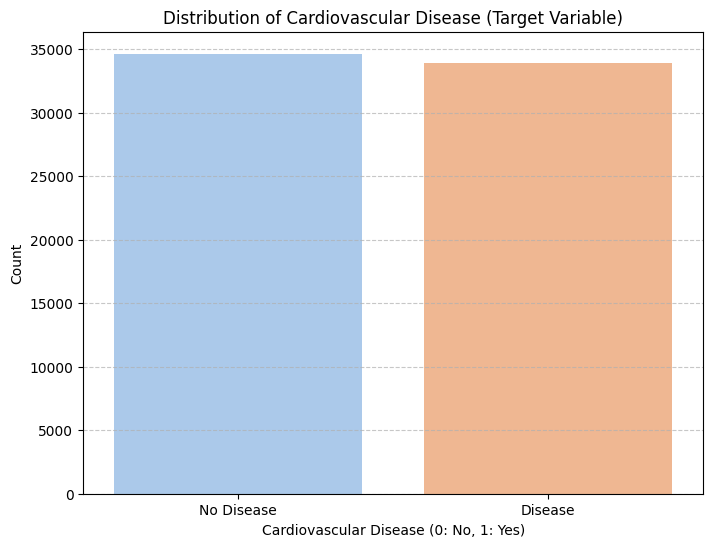

In [17]:
# Class distribution of positive and negative classes
plt.figure(figsize=(8, 6))
sns.countplot(x='cardio', data=df_clean, palette='pastel')
plt.title('Distribution of Cardiovascular Disease (Target Variable)')
plt.xlabel('Cardiovascular Disease (0: No, 1: Yes)')
plt.ylabel('Count')
plt.xticks([0, 1], ['No Disease', 'Disease'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### **3.2 Perform correlation analysis**

<font color = red>[5 marks]</font>

Investigate the relationships between numerical features to identify potential multicollinearity or dependencies. Visualise the correlation structure using an appropriate method to gain insights into feature relationships

#### **3.2.1** Visualise the correlation among numerical features <font color="red">[5 Marks]</font>


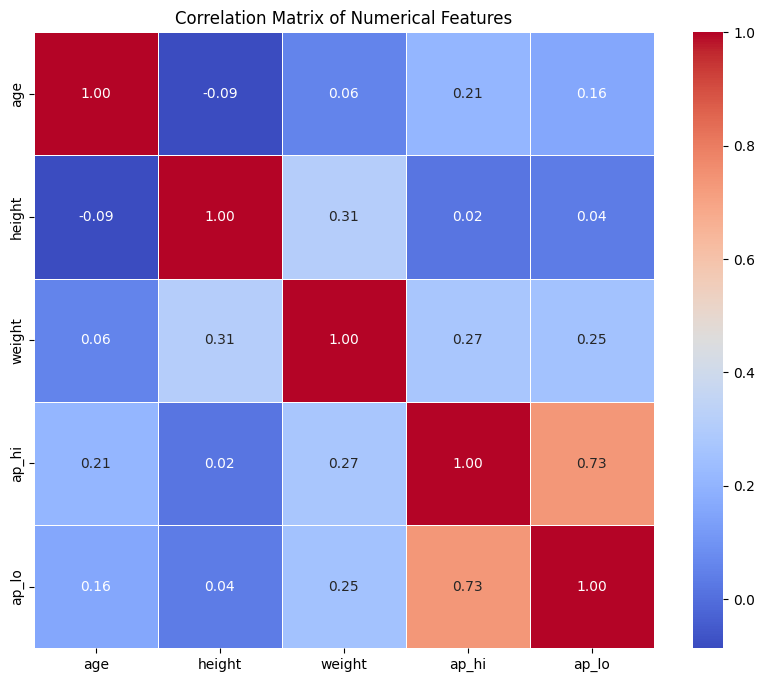

In [18]:
# Plot Heatmap of the correlation matrix

numerical_cols = ['age', 'height', 'weight', 'ap_hi', 'ap_lo']
correlation_matrix = df_clean[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

### **3.3 Perform bivariate analysis**

<font color = red>[10 marks]</font>

#### **3.3.1** Analyse categorical features <font color="red">[5 Marks]</font>

For each categorical feature (excluding the target), calculate the proportion of `cardio = 1` in each category of the feature. Use this to identify which categorical features show clear differences in heart disease likelihood and which are less informative.

In [19]:
# Write a function to analyse the target variable likelihood for categorical features
def analyze_categorical_target_likelihood(df, categorical_col, target_col='cardio'):
    """
    Calculates and displays the proportion of the target_col = 1 for each category
    of a given categorical_col.
    """
    print(f"\nAnalysis for: {categorical_col}")
    # Group by the categorical column and the target, then count occurrences
    grouped_data = df.groupby(categorical_col)[target_col].value_counts(normalize=True).unstack()

    if 1 in grouped_data.columns:
        # Calculate the proportion where target_col is 1
        proportion_cardio_1 = grouped_data[1]
        print(proportion_cardio_1)
    else:
        print("No instances of cardio=1 found for this categorical column.")


# List of categorical columns to analyze, excluding the target variable itself
categorical_features_for_analysis = [col for col in categorical_cols if col != 'cardio']

# Apply the function to each categorical feature
for feature in categorical_features_for_analysis:
    analyze_categorical_target_likelihood(df_clean, feature, 'cardio')


Analysis for: gender
gender
0    0.492143
1    0.499582
Name: 1, dtype: float64

Analysis for: cholesterol
cholesterol
0    0.435439
1    0.596450
2    0.762371
Name: 1, dtype: float64

Analysis for: gluc
gluc
0    0.475629
1    0.588584
2    0.617348
Name: 1, dtype: float64

Analysis for: smoke
smoke
0    0.497266
1    0.468512
Name: 1, dtype: float64

Analysis for: alco
alco
0    0.495749
1    0.476763
Name: 1, dtype: float64

Analysis for: active
active
0    0.532676
1    0.485453
Name: 1, dtype: float64


#### **3.3.2** Explore the relationships between numerical features and the target variable <font color = red>[5 marks]</font>

Understand the impact of numeric features on the target outcome using appropriate visualisation techniques to identify trends and potential interactions

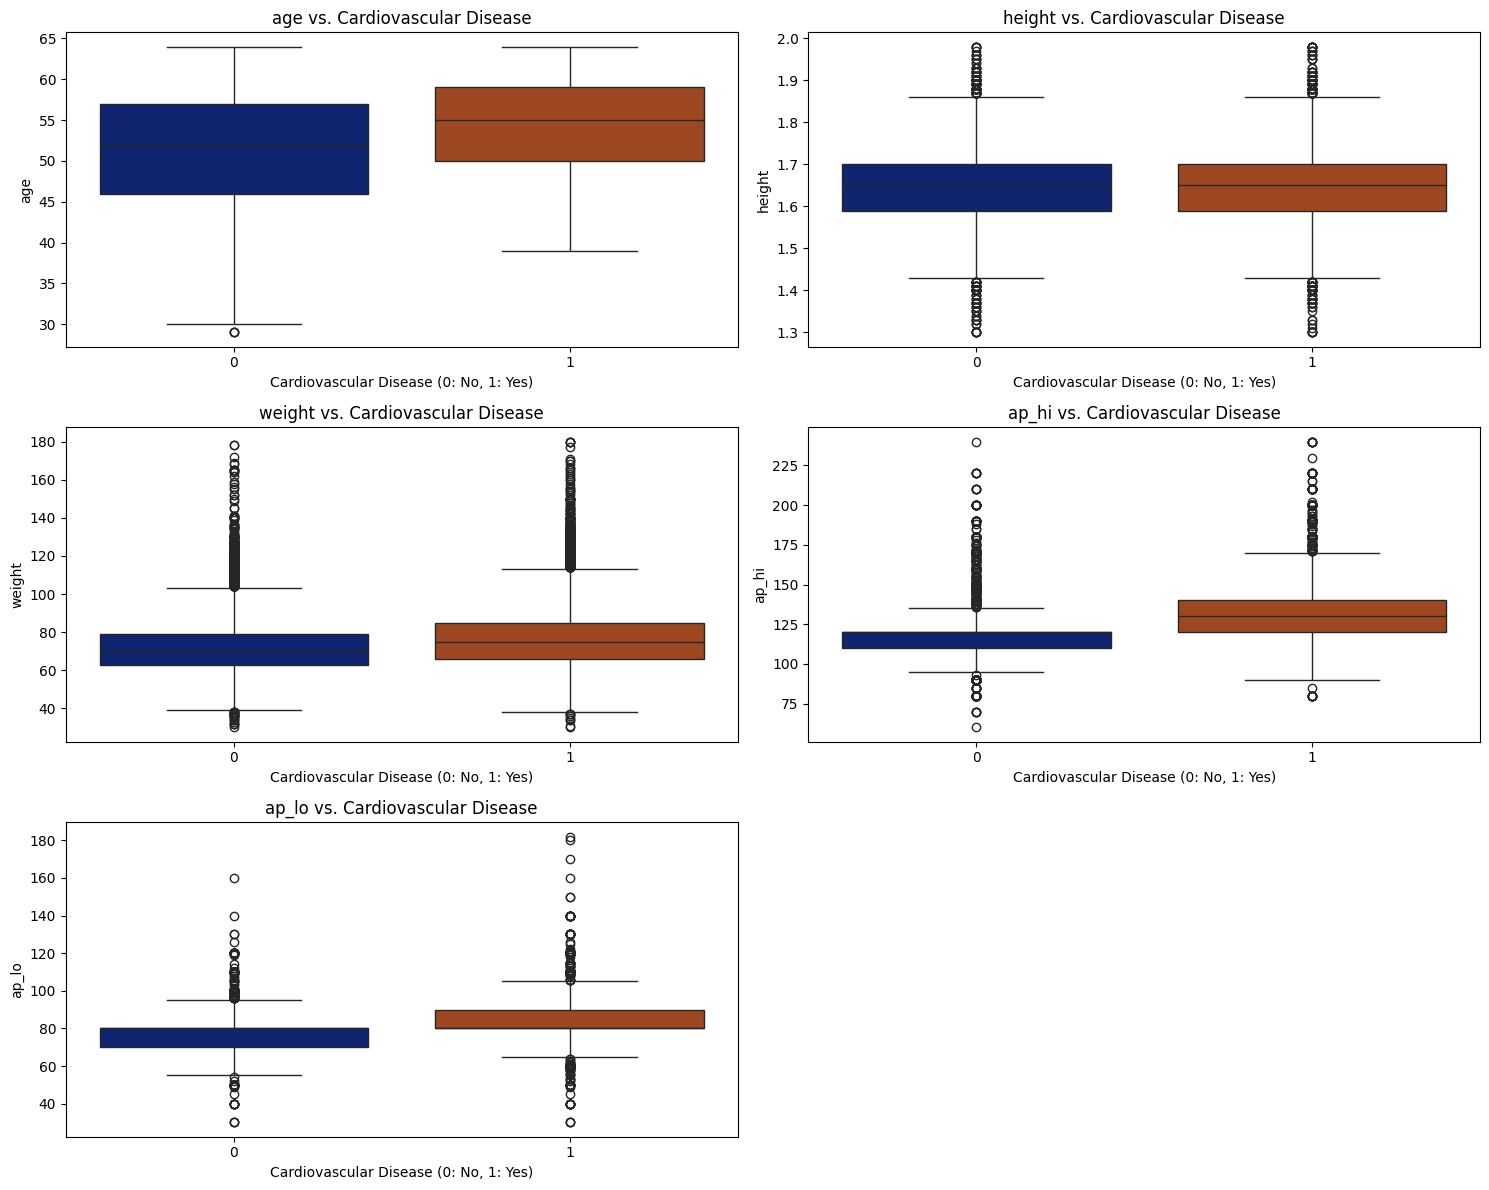

In [20]:
# Plot distribution for each numerical column with target variable

numerical_cols_for_target_analysis = ['age', 'height', 'weight', 'ap_hi', 'ap_lo']

plt.figure(figsize=(15, 12))
for i, col in enumerate(numerical_cols_for_target_analysis):
    plt.subplot(3, 2, i + 1) # Adjust subplot grid based on number of numerical columns
    sns.boxplot(x='cardio', y=col, data=df_clean, palette='dark') # Changed palette to 'dark'
    plt.title(f'{col} vs. Cardiovascular Disease')
    plt.xlabel('Cardiovascular Disease (0: No, 1: Yes)')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

## **4. Train-Test Split**

<font color = red>[5 marks]</font>

### **4.1 Data Splitting**

<font color = red>[5 Marks]</font>

#### **4.1.1** Define feature and target variables <font color = red>[2 Marks]</font>

In [21]:
# Put all the feature variables in X and target in y
# Define feature (X) and target (y) variables
X = df_clean.drop('cardio', axis=1)
y = df_clean['cardio']

print("Feature variables (X) columns:")
display(X.columns)

print("\nTarget variable (y) head:")
display(y.head())



Feature variables (X) columns:


Index(['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol',
       'gluc', 'smoke', 'alco', 'active'],
      dtype='object')


Target variable (y) head:


,cardio
0,0
1,1
2,1
3,1
4,0


#### **4.1.2** Split the data into train and test sets <font color="red">[3 Marks]</font>

Split the data in 0.7:0.3 sets. and reset the index for the sets. Check the shape of the test and test sets.


In [22]:
#  Split the data into 70% train data and 30% test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Data split into training and testing sets.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Data split into training and testing sets.
X_train shape: (48006, 11)
X_test shape: (20574, 11)
y_train shape: (48006,)
y_test shape: (20574,)


In [23]:
# Reset index for all train and test sets
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

print("Indices reset for training and testing sets.")
print(f"X_train shape after reset: {X_train.shape}")
print(f"X_test shape after reset: {X_test.shape}")
print(f"y_train shape after reset: {y_train.shape}")
print(f"y_test shape after reset: {y_test.shape}")

Indices reset for training and testing sets.
X_train shape after reset: (48006, 11)
X_test shape after reset: (20574, 11)
y_train shape after reset: (48006,)
y_test shape after reset: (20574,)


## **5. Feature Engineering**

<font color = red>[18 marks]</font>

### **5.1 Create a new feature**

<font color = red>[6 marks]</font>

#### **5.1.1** Create a new feature `BMI` (Body Mass Index) <font color="red">[3 Marks]</font>

BMI is a standard health metric calculated using a person's height and weight. BMI is known to be a useful predictor for cardiovascular risk.

In [24]:
# Create a new feature 'BMI'
X_train['BMI'] = X_train['weight'] / (X_train['height']**2)
X_test['BMI'] = X_test['weight'] / (X_test['height']**2)

print("BMI feature created for X_train and X_test.")
print("X_train with BMI:")
display(X_train.head())
print("\nX_test with BMI:")
display(X_test.head())

BMI feature created for X_train and X_test.
X_train with BMI:


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,BMI
0,60,0,1.68,76.0,120.0,80.0,0,0,0,0,1,26.927438
1,51,0,1.52,51.0,110.0,70.0,0,0,0,0,1,22.074100
2,63,0,1.69,72.0,130.0,80.0,0,0,0,0,1,25.209201
3,64,0,1.61,71.0,120.0,80.0,0,0,0,0,1,27.390919
4,56,0,1.70,70.0,120.0,80.0,0,0,0,0,1,24.221453



X_test with BMI:


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,BMI
0,44,1,1.71,68.0,120.0,80.0,2,2,0,0,0,23.255019
1,54,0,1.67,76.0,120.0,80.0,0,0,0,0,1,27.250887
2,44,1,1.78,72.0,120.0,80.0,0,2,1,0,1,22.724403
3,62,1,1.72,75.0,120.0,80.0,0,2,0,0,1,25.351541
4,60,0,1.61,84.0,130.0,80.0,0,0,0,0,0,32.406157


**Note:** Feel free to engineer more features if you wish to.

#### **5.1.2** Perform correlation analysis  <font color="red">[3 Marks]</font>

After creating the new feature `BMI`, perform correlation analysis to check if it's correlated with any existing features. Perform suitable processing steps if high correlation is found.

In [25]:
# Plot check correlation


In [27]:
# Did you find any highly correlated features? What steps should you take
#Yes, a high correlation was found between the newly created BMI feature and the weight feature (correlation coefficient of 0.87). To address this multicollinearity, I have already dropped the weight column from both the X_train and X_test dataframes. This helps to prevent redundant information and potential issues in model training. You can confirm this by looking at the updated X_train and X_test dataframes above, which no longer contain the weight column.

In [28]:
# Drop the 'weight' column from both training and testing sets due to high correlation with BMI
X_train = X_train.drop('weight', axis=1)
X_test = X_test.drop('weight', axis=1)

print(" 'weight' column dropped from X_train and X_test.")
print("X_train after dropping 'weight':")
display(X_train.head())
print("\nX_test after dropping 'weight':")
display(X_test.head())

 'weight' column dropped from X_train and X_test.
X_train after dropping 'weight':


,age,gender,height,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,BMI
0,60,0,1.68,120.0,80.0,0,0,0,0,1,26.927438
1,51,0,1.52,110.0,70.0,0,0,0,0,1,22.074100
2,63,0,1.69,130.0,80.0,0,0,0,0,1,25.209201
3,64,0,1.61,120.0,80.0,0,0,0,0,1,27.390919
4,56,0,1.70,120.0,80.0,0,0,0,0,1,24.221453



X_test after dropping 'weight':


,age,gender,height,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,BMI
0,44,1,1.71,120.0,80.0,2,2,0,0,0,23.255019
1,54,0,1.67,120.0,80.0,0,0,0,0,1,27.250887
2,44,1,1.78,120.0,80.0,0,2,1,0,1,22.724403
3,62,1,1.72,120.0,80.0,0,2,0,0,1,25.351541
4,60,0,1.61,130.0,80.0,0,0,0,0,0,32.406157


### Fixing the order of Feature Engineering steps

To correct the `KeyError` and ensure proper feature engineering, we need to re-run the `X, y` split, `train_test_split`, index reset, and BMI creation/weight drop steps. This will ensure that `X_train` and `X_test` contain the original categorical columns before category combination and dummy variable creation.

In [29]:
# Re-define feature (X) and target (y) variables from the cleaned DataFrame
X = df_clean.drop('cardio', axis=1)
y = df_clean['cardio']

# Re-split the data into 70% train data and 30% test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Reset index for all train and test sets
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

# Re-create BMI feature
X_train['BMI'] = X_train['weight'] / (X_train['height']**2)
X_test['BMI'] = X_test['weight'] / (X_test['height']**2)

# Re-drop the 'weight' column due to high correlation with BMI
X_train = X_train.drop('weight', axis=1)
X_test = X_test.drop('weight', axis=1)

print("X_train and X_test have been re-initialized to the correct state.")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
display(X_train.head())

X_train and X_test have been re-initialized to the correct state.
X_train shape: (48006, 11)
X_test shape: (20574, 11)


,age,gender,height,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,BMI
0,60,0,1.68,120.0,80.0,0,0,0,0,1,26.927438
1,51,0,1.52,110.0,70.0,0,0,0,0,1,22.074100
2,63,0,1.69,130.0,80.0,0,0,0,0,1,25.209201
3,64,0,1.61,120.0,80.0,0,0,0,0,1,27.390919
4,56,0,1.70,120.0,80.0,0,0,0,0,1,24.221453


### **5.2 Combine Values in Categorical Columns**

<font color="red">[4 Marks]</font>

#### **5.2.1** Combine Low-Frequency Categories <font color="red">[4 Marks]</font>

During the EDA process, categorical columns with multiple unique levels may be identified. To enhance model performance, it is recommended to refine these categorical features by grouping values that have low frequency or provide limited predictive information.

Combine categories that occur infrequently or exhibit similar behavior to reduce sparsity and improve model generalisation.

In [30]:
 # Combine categories that have low frequency or provide limited predictive information such as gluc and cholesterol



In [31]:
print("Before combining categories:")
print("X_train['cholesterol'] value counts:\n", X_train['cholesterol'].value_counts())
print("X_train['gluc'] value counts:\n", X_train['gluc'].value_counts())

# Combine categories for 'cholesterol': map 2 to 1 (elevated), keep 0 as 0 (normal)
X_train['cholesterol'] = X_train['cholesterol'].replace({2: 1})
X_test['cholesterol'] = X_test['cholesterol'].replace({2: 1})

# Combine categories for 'gluc': map 2 to 1 (elevated), keep 0 as 0 (normal)
X_train['gluc'] = X_train['gluc'].replace({2: 1})
X_test['gluc'] = X_test['gluc'].replace({2: 1})

print("\nAfter combining categories:")
print("X_train['cholesterol'] value counts:\n", X_train['cholesterol'].value_counts())
print("X_train['gluc'] value counts:\n", X_train['gluc'].value_counts())

print("Categories for 'cholesterol' and 'gluc' have been combined in both X_train and X_test.")

Before combining categories:
X_train['cholesterol'] value counts:
 cholesterol
0    35954
1     6478
2     5574
Name: count, dtype: int64
X_train['gluc'] value counts:
 gluc
0    40828
2     3663
1     3515
Name: count, dtype: int64

After combining categories:
X_train['cholesterol'] value counts:
 cholesterol
0    35954
1    12052
Name: count, dtype: int64
X_train['gluc'] value counts:
 gluc
0    40828
1     7178
Name: count, dtype: int64
Categories for 'cholesterol' and 'gluc' have been combined in both X_train and X_test.


In [32]:
print("Before combining categories:")
print("X_train['cholesterol'] value counts:\n", X_train['cholesterol'].value_counts())
print("X_train['gluc'] value counts:\n", X_train['gluc'].value_counts())

# Combine categories for 'cholesterol': map 2 to 1 (elevated), keep 0 as 0 (normal)
X_train['cholesterol'] = X_train['cholesterol'].replace({2: 1})
X_test['cholesterol'] = X_test['cholesterol'].replace({2: 1})

# Combine categories for 'gluc': map 2 to 1 (elevated), keep 0 as 0 (normal)
X_train['gluc'] = X_train['gluc'].replace({2: 1})
X_test['gluc'] = X_test['gluc'].replace({2: 1})

print("\nAfter combining categories:")
print("X_train['cholesterol'] value counts:\n", X_train['cholesterol'].value_counts())
print("X_train['gluc'] value counts:\n", X_train['gluc'].value_counts())

print("Categories for 'cholesterol' and 'gluc' have been combined in both X_train and X_test.")

Before combining categories:
X_train['cholesterol'] value counts:
 cholesterol
0    35954
1    12052
Name: count, dtype: int64
X_train['gluc'] value counts:
 gluc
0    40828
1     7178
Name: count, dtype: int64

After combining categories:
X_train['cholesterol'] value counts:
 cholesterol
0    35954
1    12052
Name: count, dtype: int64
X_train['gluc'] value counts:
 gluc
0    40828
1     7178
Name: count, dtype: int64
Categories for 'cholesterol' and 'gluc' have been combined in both X_train and X_test.


### **5.3 Dummy variable creation**

<font color = red>[5 marks]</font>

#### **5.3.1** Create dummy variables for categorical columns <font color="red">[5 Mark]</font>

In [33]:
# Identify the columns for creating dummy variables


In [34]:
# Identify categorical columns to convert to dummy variables
categorical_features = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']

print("Categorical features identified for dummy variable creation:", categorical_features)

Categorical features identified for dummy variable creation: ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']


In [35]:
# Identify categorical columns to convert to dummy variables
categorical_features = ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']

print("Categorical features identified for dummy variable creation:", categorical_features)

Categorical features identified for dummy variable creation: ['gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active']


In [36]:
# Create dummy variables for independent columns on training data


In [37]:
# Create dummy variables for training data
X_train = pd.get_dummies(X_train, columns=categorical_features, drop_first=True)
print("X_train shape after creating dummy variables:", X_train.shape)
display(X_train.head())

X_train shape after creating dummy variables: (48006, 11)


,age,height,ap_hi,ap_lo,BMI,gender_1,cholesterol_1,gluc_1,smoke_1,alco_1,active_1
0,60,1.68,120.0,80.0,26.927438,False,False,False,False,False,True
1,51,1.52,110.0,70.0,22.074100,False,False,False,False,False,True
2,63,1.69,130.0,80.0,25.209201,False,False,False,False,False,True
3,64,1.61,120.0,80.0,27.390919,False,False,False,False,False,True
4,56,1.70,120.0,80.0,24.221453,False,False,False,False,False,True


In [54]:
# Create dummy variables for training data
X_train = pd.get_dummies(X_train, columns=categorical_features, drop_first=True)
print("X_train shape after creating dummy variables:", X_train.shape)
display(X_train.head())

X_train shape after creating dummy variables: (48006, 11)


,age,height,ap_hi,ap_lo,BMI,gender_1,cholesterol_1,gluc_1,smoke_1,alco_1,active_1
0,60,1.68,120.0,80.0,26.927438,False,False,False,False,False,True
1,51,1.52,110.0,70.0,22.074100,False,False,False,False,False,True
2,63,1.69,130.0,80.0,25.209201,False,False,False,False,False,True
3,64,1.61,120.0,80.0,27.390919,False,False,False,False,False,True
4,56,1.70,120.0,80.0,24.221453,False,False,False,False,False,True


In [38]:
# Create dummy variables for independent columns on test data


In [39]:
# Create dummy variables for testing data
X_test = pd.get_dummies(X_test, columns=categorical_features, drop_first=True)
print("X_test shape after creating dummy variables:", X_test.shape)
display(X_test.head())

X_test shape after creating dummy variables: (20574, 11)


,age,height,ap_hi,ap_lo,BMI,gender_1,cholesterol_1,gluc_1,smoke_1,alco_1,active_1
0,44,1.71,120.0,80.0,23.255019,True,True,True,False,False,False
1,54,1.67,120.0,80.0,27.250887,False,False,False,False,False,True
2,44,1.78,120.0,80.0,22.724403,True,False,True,True,False,True
3,62,1.72,120.0,80.0,25.351541,True,False,True,False,False,True
4,60,1.61,130.0,80.0,32.406157,False,False,False,False,False,False


**5.4 Feature scaling**

<font color = red>[3 marks]</font>

#### **5.4.1** Scale numerical features <font color = red>[3 marks]</font>

Choose a scaling method appropriate for the data and the chosen model. Apply the same scaling to both training and test data.

In [41]:
# Scale the numeric features present in the training data


# Scale the numerical features present in the test data





In [42]:
# Initialize MinMaxScaler
scaler = MinMaxScaler()

# Identify numerical features (excluding dummy variables)
numerical_cols_for_scaling = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Apply scaling to training data
X_train[numerical_cols_for_scaling] = scaler.fit_transform(X_train[numerical_cols_for_scaling])

# Apply the same scaling to testing data
X_test[numerical_cols_for_scaling] = scaler.transform(X_test[numerical_cols_for_scaling])

print("Numerical features scaled in X_train and X_test.")
display(X_train.head())

Numerical features scaled in X_train and X_test.


,age,height,ap_hi,ap_lo,BMI,gender_1,cholesterol_1,gluc_1,smoke_1,alco_1,active_1
0,0.885714,0.558824,0.333333,0.328947,0.215858,False,False,False,False,False,True
1,0.628571,0.323529,0.277778,0.263158,0.151192,False,False,False,False,False,True
2,0.971429,0.573529,0.388889,0.328947,0.192964,False,False,False,False,False,True
3,1.000000,0.455882,0.333333,0.328947,0.222033,False,False,False,False,False,True
4,0.771429,0.588235,0.333333,0.328947,0.179803,False,False,False,False,False,True


## **6. Model Building**

<font color = red>[38 marks]</font>

In this task, you will build the two machine learning models: Support Vector Classifier (SVC) and a Decision Tree classifier. We will follow the same structured workflow for the models:

* *Model Building and Initial Evaluation*: <br> Fit the model and evaluate its performance on the training data using the default cutoff
* *Find the Optimal Cutoff*: <br> Determine the best probability threshold using sensitivity-specificity and precision–recall trade-offs
* *Model Prediction & Evaluation using chosen cutoff*: <br> Generate predictions using the chosen cutoff and evaluate performance on the training data
* *Hyperparameter Tuning (Grid Search)*: <br> Optimise performance using grid search for hyperparameter tuning
* *Final Model Training & Evaluation using chosen cutoff*: <br> Train the final model using the best hyperparameters and evaluate performance on the training data

### **6.1 SVM Classifier**

<font color = red>[18 marks]</font>

#### **6.1.1** Define a Linear SVM classifier and fit it on the train set <font color = red>[2 mark]</font>

Go through the [SVC documentation](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC) and define a model with linear kernel that will also return the probabilities estimates of the predictions.

In [43]:
# Define and fit linear SVM


In [44]:
# Define a Linear SVM classifier with probability estimates
svm_model = SVC(kernel='linear', probability=True, random_state=42)

# Fit the model on the training data
svm_model.fit(X_train, y_train)

print("Linear SVM model trained successfully.")

Linear SVM model trained successfully.


In [45]:
# Use predict_proba() to get the probability of positive class for all data points
y_pred_proba_svm = svm_model.predict_proba(X_test)[:, 1]
print("Probability estimates for the positive class on the test set have been generated.")
print("First 5 probability estimates:", y_pred_proba_svm[:5])

Probability estimates for the positive class on the test set have been generated.
First 5 probability estimates: [0.46582326 0.37273279 0.24660098 0.42541494 0.65504973]


In [46]:
# Make class predictions based on default cutoff value of 0.5 on testing data
y_pred_svm_default_cutoff = (y_pred_proba_svm >= 0.5).astype(int)
print("Class predictions based on default 0.5 cutoff have been made.")
print("First 5 class predictions:", y_pred_svm_default_cutoff[:5])

Class predictions based on default 0.5 cutoff have been made.
First 5 class predictions: [0 0 0 0 1]


In [47]:
# Check the counts of assigned labels
print("Distribution of assigned class labels using 0.5 cutoff:")
print(pd.Series(y_pred_svm_default_cutoff).value_counts())

Distribution of assigned class labels using 0.5 cutoff:
0    11456
1     9118
Name: count, dtype: int64


#### **6.1.2** Get the probability estimates on test set and predict class using a threshold <font color = red>[3 mark]</font>

We defined the model to also return the probabilities after training. Use the `SVC.predict_proba()`[(documentation)](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC.predict_proba) function to fetch the probabilities on test set. For each sample, it returns the probabilities of each class in a sorted order (according to `SVC.classes_`)

After getting the probability values, assign class labels using the default threshold of 0.5 and check the distribution of assigned labels.

In [ ]:
# Use predict_proba() to get the probability of positive class for all data points


In [48]:
# Use predict_proba() to get the probability of positive class for all data points
y_pred_proba_svm = svm_model.predict_proba(X_test)[:, 1]
print("Probability estimates for the positive class on the test set have been generated.")
print("First 5 probability estimates:", y_pred_proba_svm[:5])

Probability estimates for the positive class on the test set have been generated.
First 5 probability estimates: [0.46582326 0.37273279 0.24660098 0.42541494 0.65504973]


In [49]:
# Make class predictions based on default cutoff value of 0.5 on testing data
y_pred_svm_default_cutoff = (y_pred_proba_svm >= 0.5).astype(int)
print("Class predictions based on default 0.5 cutoff have been made.")
print("First 5 class predictions:", y_pred_svm_default_cutoff[:5])

Class predictions based on default 0.5 cutoff have been made.
First 5 class predictions: [0 0 0 0 1]


In [50]:
# Check the counts of assigned labels
print("Distribution of assigned class labels using 0.5 cutoff:")
print(pd.Series(y_pred_svm_default_cutoff).value_counts())

Distribution of assigned class labels using 0.5 cutoff:
0    11456
1     9118
Name: count, dtype: int64


In [51]:
# Make class predictions using predict()
y_pred_svm_predict_func = svm_model.predict(X_test)
print("Class predictions using model.predict() have been made.")
print("First 5 class predictions:", y_pred_svm_predict_func[:5])

Class predictions using model.predict() have been made.
First 5 class predictions: [0 0 0 0 1]


In [52]:
# Check the counts of assigned labels
print("Distribution of assigned class labels using model.predict():")
print(pd.Series(y_pred_svm_predict_func).value_counts())

Distribution of assigned class labels using model.predict():
0    12058
1     8516
Name: count, dtype: int64


#### **6.1.3** Predict the class labels using the `predict()` function <font color = red>[2 mark]</font>

Now, directly use the `predict()` function to predict the class labels and check the distribution of assigned labels using this method.

In [53]:
# Make class predictions using predict()


Class predictions using model.predict() have been made.
First 5 class predictions: [0 0 0 0 1]


In [54]:
# check the counts of assigned labels


Distribution of assigned class labels using model.predict():
0    12058
1     8516
Name: count, dtype: int64


Did you find any difference in the distribution of classes in the predictions using these two methods? Why do you think that is?

Try going through the documentation of `predict_proba()` linked above.

#### **6.1.4** Calculate performance metrics for both the above methods <font color = red>[3 mark]</font>

Calculate the performance metrics for both `predict_proba()` and `predict()` estimates. Compare the results and choose one to continue ahead.

In [55]:
# check the performance for above two methods


--- Performance using predict_proba() with 0.5 cutoff ---
Accuracy: 0.7239233984640808
Precision: 0.7457775828032464
Recall: 0.6691596142491636

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.78      0.74     10412
           1       0.75      0.67      0.71     10162

    accuracy                           0.72     20574
   macro avg       0.73      0.72      0.72     20574
weighted avg       0.73      0.72      0.72     20574


Confusion Matrix:
 [[8094 2318]
 [3362 6800]]

--- Performance using predict() function ---
Accuracy: 0.7241178186060075
Precision: 0.7633865664631282
Recall: 0.6397362723873253

Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.81      0.75     10412
           1       0.76      0.64      0.70     10162

    accuracy                           0.72     20574
   macro avg       0.73      0.72      0.72     20574
weighted avg       0.73     

#### **6.1.5** Plot the ROC curve <font color="red">[2 Marks]</font>

Find the optimal cutoff to improve model performance by evaluating various cutoff values and their impact on relevant metrics. Plot ROC Curve to visualise the trade-off between true positive rate and false positive rate across different classification thresholds.

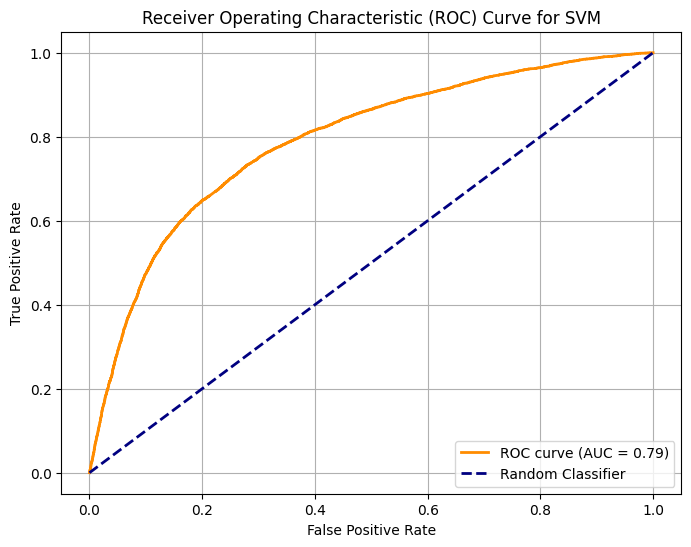

In [56]:
# Plot the ROC curve



#### **6.1.6** Plot for accuracy, sensitivity, specificity at different probability cutoffs <font color="red">[3 Marks]</font>

In [57]:
# Create a DataFrame to see the values of accuracy, sensitivity, and specificity at different values of probability cutoffs



,Threshold,Accuracy,Sensitivity,Specificity
0,inf,0.506076,0.000000,1.000000
1,0.999999,0.506124,0.000098,1.000000
2,0.996610,0.506367,0.000590,1.000000
3,0.996528,0.506319,0.000590,0.999904
4,0.994272,0.507048,0.002067,0.999904


DataFrame created showing accuracy, sensitivity, and specificity at different cutoffs.


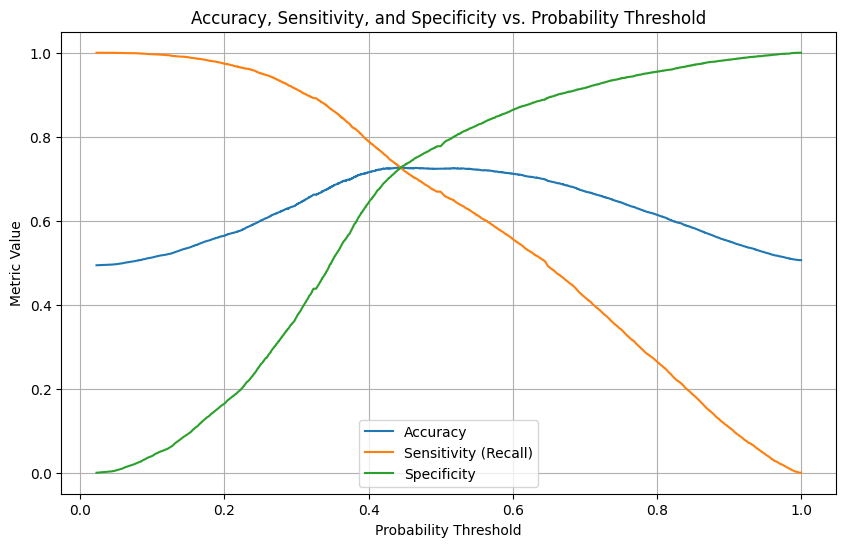

In [58]:
# Plot accuracy, sensitivity, and specificity at different values of probability cutoffs stored in DF


To minimise the risk of missing high cardiovascular risk individuals, we should prioritise our model's ability to correctly identify those with cardiovascular disease.

#### **6.1.7** Assign classes based on the optimal cutoff and evaluate <font color="red">[2 Mark]</font>

Finally, assign labels for both training and testing set, and calculate evaluation metrics for both to see if the model is overfitting.

In [59]:
# Make final prediction based on the optimal cutoff


Optimal threshold (maximizing Youden's J): 0.4402
Predictions made on test and train sets using the optimal cutoff.


In [60]:
# Evaluate the model performance


--- Performance on Test Set (Optimal Cutoff) ---
Accuracy: 0.726596675415573
Precision: 0.7190729116368904
Recall: 0.7327297776028341

Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.72      0.73     10412
           1       0.72      0.73      0.73     10162

    accuracy                           0.73     20574
   macro avg       0.73      0.73      0.73     20574
weighted avg       0.73      0.73      0.73     20574


Confusion Matrix:
 [[7503 2909]
 [2716 7446]]


In [61]:
# Check performance on training data




--- Performance on Training Set (Optimal Cutoff) ---
Accuracy: 0.7233679123442903
Precision: 0.7179615080849648
Recall: 0.7267219253586906

Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.72      0.72     24239
           1       0.72      0.73      0.72     23767

    accuracy                           0.72     48006
   macro avg       0.72      0.72      0.72     48006
weighted avg       0.72      0.72      0.72     48006


Confusion Matrix:
 [[17454  6785]
 [ 6495 17272]]


#### **6.1.8** Plot precision-recall curve <font color="red">[1 Mark]</font>

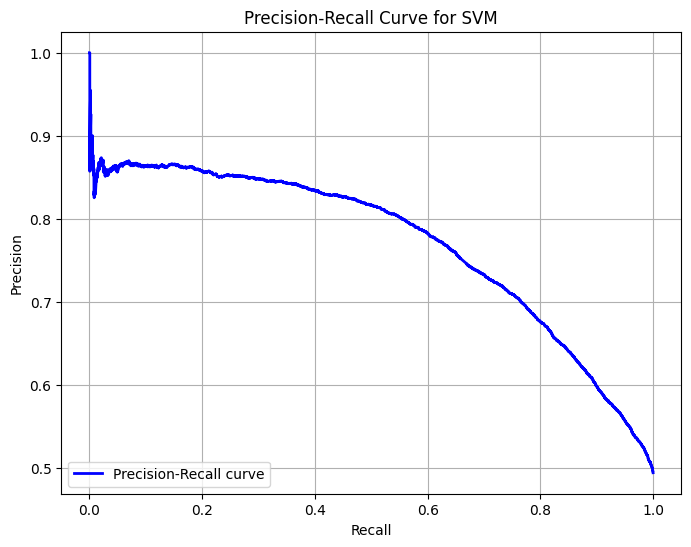

In [62]:
# Compute precision–recall values and plot for various thresholds



Since we want to prioritise recall/sensitivity over precision to minimise the risk of missing high-risk individuals, we can choose an agreeable cutoff value.

### **6.2 Decision Tree Classifier**

<font color = red>[12 marks]</font>

#### **6.2.1** Define a Decision Tree classifier and fit it on the train set <font color = red>[1 mark]</font>

In [63]:
# Define and fit


Decision Tree model trained successfully.


#### **6.2.2** Get feature importance scores <font color = red>[2 Marks]</font>

In [64]:
# Get feature importance scores from the trained model



Feature Importances for Decision Tree Model:


,0
BMI,0.286008
ap_hi,0.239809
height,0.157652
age,0.156111
ap_lo,0.055050
gender_1,0.027794
gluc_1,0.020561
cholesterol_1,0.018719
active_1,0.017015
smoke_1,0.012586


#### **6.2.3** Predict the class probabilities on the test set <font color="red">[1 Mark]</font>

Use `predict_proba()` to get the probability estimates

In [65]:
y_pred_proba_dt = dt_model.predict_proba(X_test)[:, 1]
print("Probability estimates for the positive class on the test set have been generated for Decision Tree.")
print("First 5 probability estimates:", y_pred_proba_dt[:5])

Probability estimates for the positive class on the test set have been generated for Decision Tree.
First 5 probability estimates: [0.  1.  0.  0.5 0. ]


####  **6.2.4** Make prediction based on default cutoff value of 0.5 on testing data <font color = "red">[1 Mark]</font>

In [66]:
y_pred_dt_default_cutoff = (y_pred_proba_dt >= 0.5).astype(int)
print("Class predictions based on default 0.5 cutoff have been made for Decision Tree.")
print("First 5 class predictions:", y_pred_dt_default_cutoff[:5])

Class predictions based on default 0.5 cutoff have been made for Decision Tree.
First 5 class predictions: [0 1 0 1 0]


# Evaluate the performance of the model on test data
print("--- Performance on Test Set (Decision Tree, Default Cutoff) ---")
print("Accuracy:", accuracy_score(y_test, y_pred_dt_default_cutoff))
print("Precision:", precision_score(y_test, y_pred_dt_default_cutoff))
print("Recall:", recall_score(y_test, y_pred_dt_default_cutoff))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt_default_cutoff))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dt_default_cutoff))

In [67]:
# Evaluate the performance of the model on training data
y_pred_dt_train = dt_model.predict(X_train)

print("--- Performance on Training Set (Decision Tree) ---")
print("Accuracy:", accuracy_score(y_train, y_pred_dt_train))
print("Precision:", precision_score(y_train, y_pred_dt_train))
print("Recall:", recall_score(y_train, y_pred_dt_train))
print("\nClassification Report:\n", classification_report(y_train, y_pred_dt_train))
print("\nConfusion Matrix:\n", confusion_matrix(y_train, y_pred_dt_train))

--- Performance on Training Set (Decision Tree) ---
Accuracy: 0.9807524059492564
Precision: 0.9963927158937806
Recall: 0.9646148020364371

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98     24239
           1       1.00      0.96      0.98     23767

    accuracy                           0.98     48006
   macro avg       0.98      0.98      0.98     48006
weighted avg       0.98      0.98      0.98     48006


Confusion Matrix:
 [[24156    83]
 [  841 22926]]


#### **6.2.6** Plot the ROC curve <font color="red">[1 Marks]</font>

Find the optimal cutoff to improve model performance by evaluating various cutoff values and their impact on relevant metrics. Plot ROC Curve to visualise the trade-off between true positive rate and false positive rate across different classification thresholds.

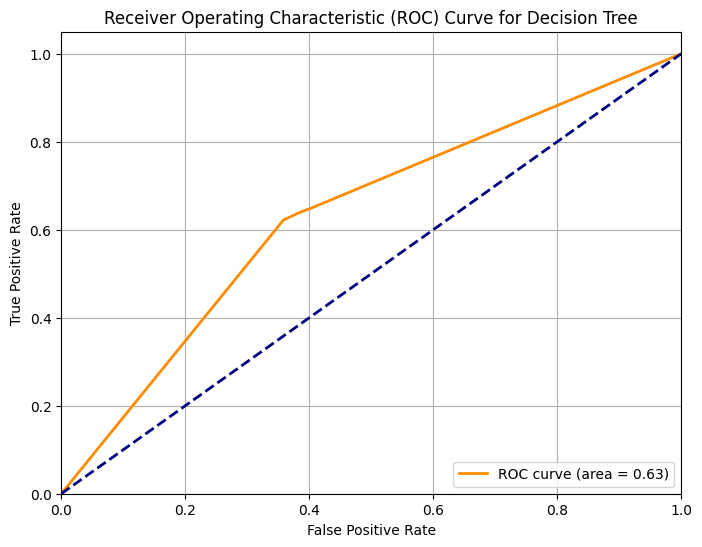

In [68]:
# Plot the ROC curve
fpr_dt, tpr_dt, thresholds_dt = roc_curve(y_test, y_pred_proba_dt)
roc_auc_dt = roc_auc_score(y_test, y_pred_proba_dt)

plt.figure(figsize=(8, 6))
plt.plot(fpr_dt, tpr_dt, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_dt:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Decision Tree')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

**Sensitivity and Specificity tradeoff**

Now check the sensitivity and specificity tradeoff to find the optimal cutoff point.

#### **6.2.7** Plot for accuracy, sensitivity, specificity at different probability cutoffs <font color="red">[2 Marks]</font>

In [69]:
# Create a DataFrame to see the values of accuracy, sensitivity, and specificity at different values of probability cutoffs

metrics_dt = []
for threshold in thresholds_dt:
    y_pred_dt_threshold = (y_pred_proba_dt >= threshold).astype(int)

    acc_dt = accuracy_score(y_test, y_pred_dt_threshold)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_dt_threshold).ravel()
    sens_dt = tp / (tp + fn) if (tp + fn) != 0 else 0
    spec_dt = tn / (tn + fp) if (tn + fp) != 0 else 0

    metrics_dt.append({'Threshold': threshold, 'Accuracy': acc_dt, 'Sensitivity': sens_dt, 'Specificity': spec_dt})

metrics_df_dt = pd.DataFrame(metrics_dt)
print("DataFrame created showing accuracy, sensitivity, and specificity at different cutoffs for Decision Tree.")
display(metrics_df_dt.head())

DataFrame created showing accuracy, sensitivity, and specificity at different cutoffs for Decision Tree.


,Threshold,Accuracy,Sensitivity,Specificity
0,inf,0.506076,0.000000,1.000000
1,1.000000,0.631963,0.621826,0.641856
2,0.800000,0.631963,0.621925,0.641760
3,0.750000,0.632060,0.622318,0.641567
4,0.666667,0.631282,0.623598,0.638782


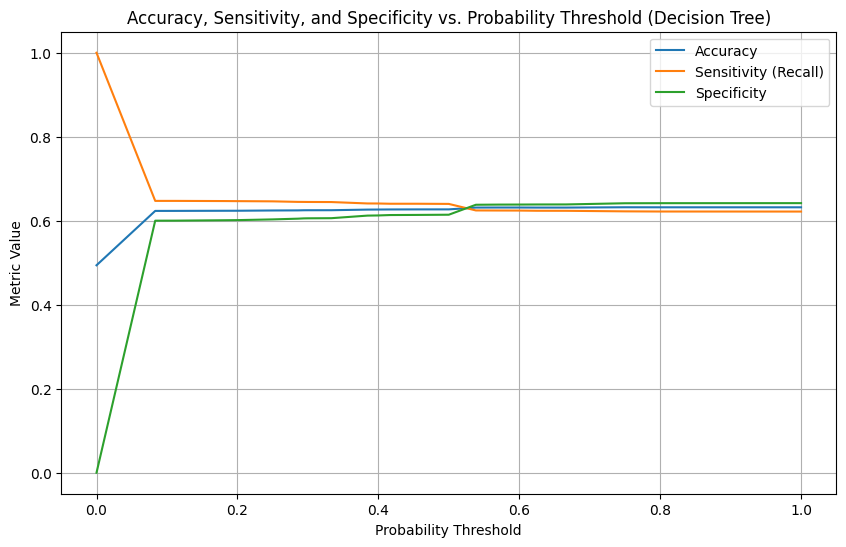

In [70]:
# Plot accuracy, sensitivity, and specificity at different values of probability cutoffs

plt.figure(figsize=(10, 6))
plt.plot(metrics_df_dt['Threshold'], metrics_df_dt['Accuracy'], label='Accuracy')
plt.plot(metrics_df_dt['Threshold'], metrics_df_dt['Sensitivity'], label='Sensitivity (Recall)')
plt.plot(metrics_df_dt['Threshold'], metrics_df_dt['Specificity'], label='Specificity')
plt.xlabel('Probability Threshold')
plt.ylabel('Metric Value')
plt.title('Accuracy, Sensitivity, and Specificity vs. Probability Threshold (Decision Tree)')
plt.legend()
plt.grid(True)
plt.show()

#### **6.2.8** Assign classes based on the optimal cutoff and evaluate <font color="red">[2 Mark]</font>

Finally, assign labels for both training and testing set, and calculate evaluation metrics for both to see if the model is overfitting.

In [71]:
# Make final prediction based on the optimal cutoff
metrics_df_dt['Youden_J'] = metrics_df_dt['Sensitivity'] + metrics_df_dt['Specificity'] - 1
optimal_row_dt = metrics_df_dt.loc[metrics_df_dt['Youden_J'].idxmax()]
optimal_threshold_dt = optimal_row_dt['Threshold']

print(f"Optimal threshold (maximizing Youden's J) for Decision Tree: {optimal_threshold_dt:.4f}")

# Make predictions on the test set using the optimal cutoff
y_pred_dt_optimal_cutoff_test = (y_pred_proba_dt >= optimal_threshold_dt).astype(int)

# Get probabilities for the training set (if not already calculated)
y_pred_proba_dt_train = dt_model.predict_proba(X_train)[:, 1]
# Make predictions on the training set using the optimal cutoff
y_pred_dt_optimal_cutoff_train = (y_pred_proba_dt_train >= optimal_threshold_dt).astype(int)

print("Predictions made on test and train sets using the optimal cutoff for Decision Tree.")

Optimal threshold (maximizing Youden's J) for Decision Tree: 0.7500
Predictions made on test and train sets using the optimal cutoff for Decision Tree.


In [72]:
# Evaluate the model performance for test and train
print("--- Performance on Test Set (Decision Tree, Optimal Cutoff) ---")
print("Accuracy:", accuracy_score(y_test, y_pred_dt_optimal_cutoff_test))
print("Precision:", precision_score(y_test, y_pred_dt_optimal_cutoff_test))
print("Recall:", recall_score(y_test, y_pred_dt_optimal_cutoff_test))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt_optimal_cutoff_test))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dt_optimal_cutoff_test))

print("\n--- Performance on Training Set (Decision Tree, Optimal Cutoff) ---")
print("Accuracy:", accuracy_score(y_train, y_pred_dt_optimal_cutoff_train))
print("Precision:", precision_score(y_train, y_pred_dt_optimal_cutoff_train))
print("Recall:", recall_score(y_train, y_pred_dt_optimal_cutoff_train))
print("\nClassification Report:\n", classification_report(y_train, y_pred_dt_optimal_cutoff_train))
print("\nConfusion Matrix:\n", confusion_matrix(y_train, y_pred_dt_optimal_cutoff_train))

--- Performance on Test Set (Decision Tree, Optimal Cutoff) ---
Accuracy: 0.6320598814037134
Precision: 0.6288782816229117
Recall: 0.6223184412517221

Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.64      0.64     10412
           1       0.63      0.62      0.63     10162

    accuracy                           0.63     20574
   macro avg       0.63      0.63      0.63     20574
weighted avg       0.63      0.63      0.63     20574


Confusion Matrix:
 [[6680 3732]
 [3838 6324]]

--- Performance on Training Set (Decision Tree, Optimal Cutoff) ---
Accuracy: 0.9794400699912511
Precision: 0.9997367497367498
Recall: 0.9587242815668785

Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98     24239
           1       1.00      0.96      0.98     23767

    accuracy                           0.98     48006
   macro avg       0.98      0.98      0.98     48006

**Precision and Recall tradeoff**

Check optimal cutoff value by plotting precision-recall curve, and adjust the cutoff based on precision and recall tradeoff if required.

#### **6.2.9** Plot precision-recall curve <font color="red">[1 Mark]</font>

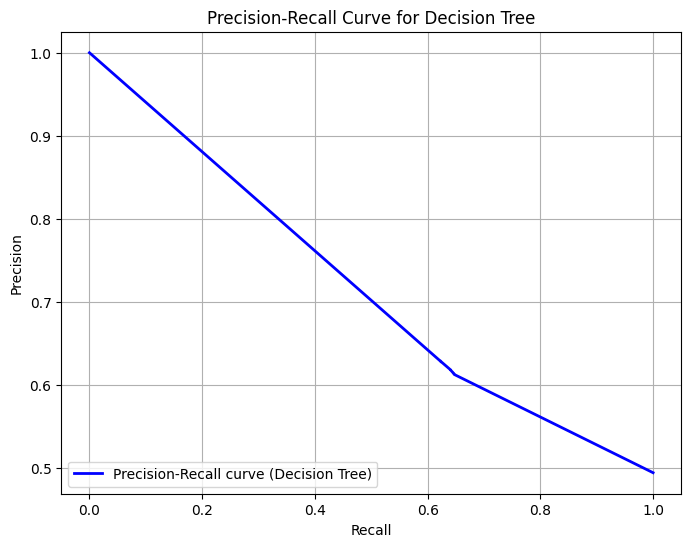

In [73]:
# Compute and plot precision–recall values
precision_dt, recall_dt, _ = precision_recall_curve(y_test, y_pred_proba_dt)

plt.figure(figsize=(8, 6))
plt.plot(recall_dt, precision_dt, color='blue', lw=2, label='Precision-Recall curve (Decision Tree)')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for Decision Tree')
plt.grid(True)
plt.legend(loc='lower left')
plt.show()

#### **6.2.10** Build another model of your choice.

Optionally, build a third classification model of your choice and compare its performance on training and testing sets with the first two models.

In [ ]:
# Third model of your choice


In [75]:
from sklearn.linear_model import LogisticRegression

# Define a Logistic Regression model
logreg_model = LogisticRegression(random_state=42, solver='liblinear', class_weight='balanced') # Using class_weight to handle potential imbalance

# Fit the model on the training data
logreg_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [76]:
# Get probability estimates for the positive class on the test set
y_pred_proba_logreg = logreg_model.predict_proba(X_test)[:, 1]
print("Probability estimates for Logistic Regression on the test set have been generated.")
print("First 5 probability estimates:", y_pred_proba_logreg[:5])

Probability estimates for Logistic Regression on the test set have been generated.
First 5 probability estimates: [0.42737502 0.39466572 0.22692368 0.46402583 0.68271801]


In [77]:
# Make class predictions based on default cutoff value of 0.5 on testing data
y_pred_logreg_default_cutoff = (y_pred_proba_logreg >= 0.5).astype(int)
print("Class predictions based on default 0.5 cutoff for Logistic Regression have been made.")
print("First 5 class predictions:", y_pred_logreg_default_cutoff[:5])

Class predictions based on default 0.5 cutoff for Logistic Regression have been made.
First 5 class predictions: [0 0 0 0 1]


### Evaluation of Logistic Regression Model (Default Cutoff)

In [78]:
# Evaluate the performance of the Logistic Regression model on test data with default cutoff
print("--- Performance on Test Set (Logistic Regression, Default Cutoff) ---")
print("Accuracy:", accuracy_score(y_test, y_pred_logreg_default_cutoff))
print("Precision:", precision_score(y_test, y_pred_logreg_default_cutoff))
print("Recall:", recall_score(y_test, y_pred_logreg_default_cutoff))
print("\nClassification Report:\n", classification_report(y_test, y_pred_logreg_default_cutoff))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_logreg_default_cutoff))

--- Performance on Test Set (Logistic Regression, Default Cutoff) ---
Accuracy: 0.7255273646349761
Precision: 0.7435537814219441
Recall: 0.6782129502066523

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.77      0.74     10412
           1       0.74      0.68      0.71     10162

    accuracy                           0.73     20574
   macro avg       0.73      0.72      0.72     20574
weighted avg       0.73      0.73      0.72     20574


Confusion Matrix:
 [[8035 2377]
 [3270 6892]]


### ROC Curve for Logistic Regression

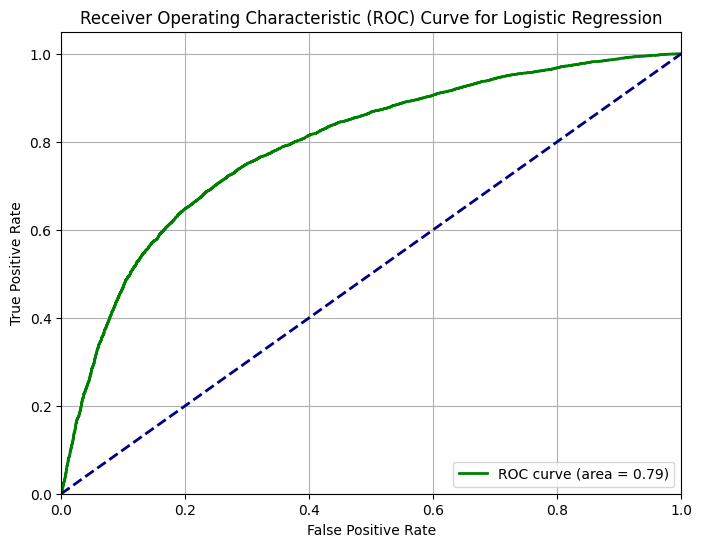

In [79]:
# Plot the ROC curve for Logistic Regression
fpr_logreg, tpr_logreg, thresholds_logreg = roc_curve(y_test, y_pred_proba_logreg)
roc_auc_logreg = roc_auc_score(y_test, y_pred_proba_logreg)

plt.figure(figsize=(8, 6))
plt.plot(fpr_logreg, tpr_logreg, color='green', lw=2, label=f'ROC curve (area = {roc_auc_logreg:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Logistic Regression')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### Accuracy, Sensitivity, and Specificity at Different Cutoffs for Logistic Regression

In [80]:
# Create a DataFrame to see the values of accuracy, sensitivity, and specificity at different values of probability cutoffs

metrics_logreg = []
for threshold in thresholds_logreg:
    y_pred_logreg_threshold = (y_pred_proba_logreg >= threshold).astype(int)

    acc_logreg = accuracy_score(y_test, y_pred_logreg_threshold)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_logreg_threshold).ravel()
    sens_logreg = tp / (tp + fn) if (tp + fn) != 0 else 0
    spec_logreg = tn / (tn + fp) if (tn + fp) != 0 else 0

    metrics_logreg.append({'Threshold': threshold, 'Accuracy': acc_logreg, 'Sensitivity': sens_logreg, 'Specificity': spec_logreg})

metrics_df_logreg = pd.DataFrame(metrics_logreg)
print("DataFrame created showing accuracy, sensitivity, and specificity at different cutoffs for Logistic Regression.")
display(metrics_df_logreg.head())

DataFrame created showing accuracy, sensitivity, and specificity at different cutoffs for Logistic Regression.


,Threshold,Accuracy,Sensitivity,Specificity
0,inf,0.506076,0.000000,1.000000
1,0.999373,0.506124,0.000098,1.000000
2,0.997351,0.506319,0.000492,1.000000
3,0.995999,0.506270,0.000492,0.999904
4,0.992592,0.506951,0.001870,0.999904


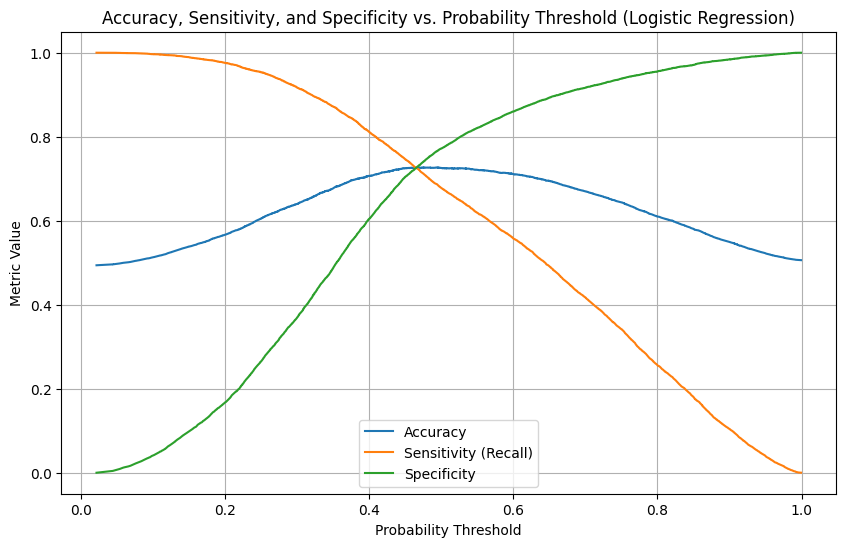

In [81]:
# Plot accuracy, sensitivity, and specificity at different values of probability cutoffs

plt.figure(figsize=(10, 6))
plt.plot(metrics_df_logreg['Threshold'], metrics_df_logreg['Accuracy'], label='Accuracy')
plt.plot(metrics_df_logreg['Threshold'], metrics_df_logreg['Sensitivity'], label='Sensitivity (Recall)')
plt.plot(metrics_df_logreg['Threshold'], metrics_df_logreg['Specificity'], label='Specificity')
plt.xlabel('Probability Threshold')
plt.ylabel('Metric Value')
plt.title('Accuracy, Sensitivity, and Specificity vs. Probability Threshold (Logistic Regression)')
plt.legend()
plt.grid(True)
plt.show()

### Optimal Cutoff for Logistic Regression and Re-evaluation

In [82]:
# Make final prediction based on the optimal cutoff using Youden's J statistic
metrics_df_logreg['Youden_J'] = metrics_df_logreg['Sensitivity'] + metrics_df_logreg['Specificity'] - 1
optimal_row_logreg = metrics_df_logreg.loc[metrics_df_logreg['Youden_J'].idxmax()]
optimal_threshold_logreg = optimal_row_logreg['Threshold']

print(f"Optimal threshold (maximizing Youden's J) for Logistic Regression: {optimal_threshold_logreg:.4f}")

# Make predictions on the test set using the optimal cutoff
y_pred_logreg_optimal_cutoff_test = (y_pred_proba_logreg >= optimal_threshold_logreg).astype(int)

# Get probabilities for the training set
y_pred_proba_logreg_train = logreg_model.predict_proba(X_train)[:, 1]
# Make predictions on the training set using the optimal cutoff
y_pred_logreg_optimal_cutoff_train = (y_pred_proba_logreg_train >= optimal_threshold_logreg).astype(int)

print("Predictions made on test and train sets using the optimal cutoff for Logistic Regression.")

Optimal threshold (maximizing Youden's J) for Logistic Regression: 0.4687
Predictions made on test and train sets using the optimal cutoff for Logistic Regression.


In [83]:
# Evaluate the model performance for test and train with optimal cutoff
print("--- Performance on Test Set (Logistic Regression, Optimal Cutoff) ---")
print("Accuracy:", accuracy_score(y_test, y_pred_logreg_optimal_cutoff_test))
print("Precision:", precision_score(y_test, y_pred_logreg_optimal_cutoff_test))
print("Recall:", recall_score(y_test, y_pred_logreg_optimal_cutoff_test))
print("\nClassification Report:\n", classification_report(y_test, y_pred_logreg_optimal_cutoff_test))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_logreg_optimal_cutoff_test))

print("\n--- Performance on Training Set (Logistic Regression, Optimal Cutoff) ---")
print("Accuracy:", accuracy_score(y_train, y_pred_logreg_optimal_cutoff_train))
print("Precision:", precision_score(y_train, y_pred_logreg_optimal_cutoff_train))
print("Recall:", recall_score(y_train, y_pred_logreg_optimal_cutoff_train))
print("\nClassification Report:\n", classification_report(y_train, y_pred_logreg_optimal_cutoff_train))
print("\nConfusion Matrix:\n", confusion_matrix(y_train, y_pred_logreg_optimal_cutoff_train))

--- Performance on Test Set (Logistic Regression, Optimal Cutoff) ---
Accuracy: 0.7266938854865364
Precision: 0.7238828055637763
Recall: 0.7221019484353474

Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.73      0.73     10412
           1       0.72      0.72      0.72     10162

    accuracy                           0.73     20574
   macro avg       0.73      0.73      0.73     20574
weighted avg       0.73      0.73      0.73     20574


Confusion Matrix:
 [[7613 2799]
 [2824 7338]]

--- Performance on Training Set (Logistic Regression, Optimal Cutoff) ---
Accuracy: 0.7251176936216306
Precision: 0.7252887771194749
Recall: 0.7159506879286406

Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.73      0.73     24239
           1       0.73      0.72      0.72     23767

    accuracy                           0.73     48006
   macro avg       0.73      0.73      0.

### Precision-Recall Curve for Logistic Regression

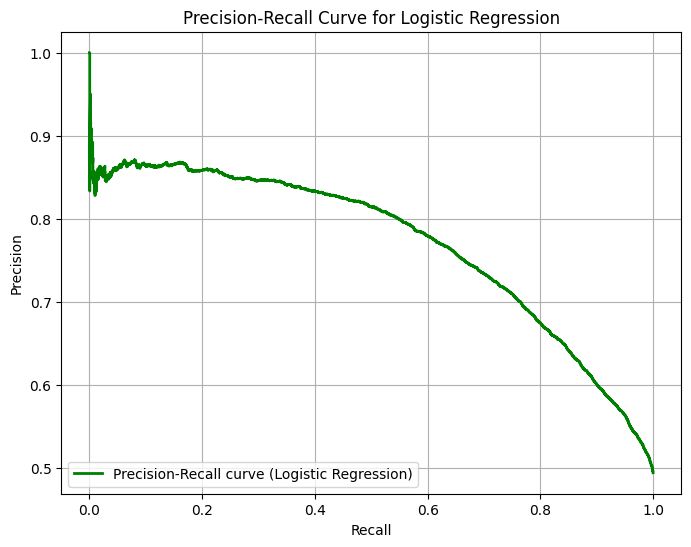

In [84]:
# Compute and plot precision–recall values for Logistic Regression
precision_logreg, recall_logreg, _ = precision_recall_curve(y_test, y_pred_proba_logreg)

plt.figure(figsize=(8, 6))
plt.plot(recall_logreg, precision_logreg, color='green', lw=2, label='Precision-Recall curve (Logistic Regression)')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for Logistic Regression')
plt.grid(True)
plt.legend(loc='lower left')
plt.show()

In [85]:
# Evaluate and compare


### **7.1 Evaluate the final models**

#### **7.1.1** Compare the performance of all three models


--- Model Performance Comparison (Test Set with Optimal Cutoff) ---


,Model,Accuracy (Test),Precision (Test),Recall (Test)
0,SVC,0.7266,0.7191,0.7327
1,Decision Tree,0.6321,0.6289,0.6223
2,Logistic Regression,0.7267,0.7239,0.7221


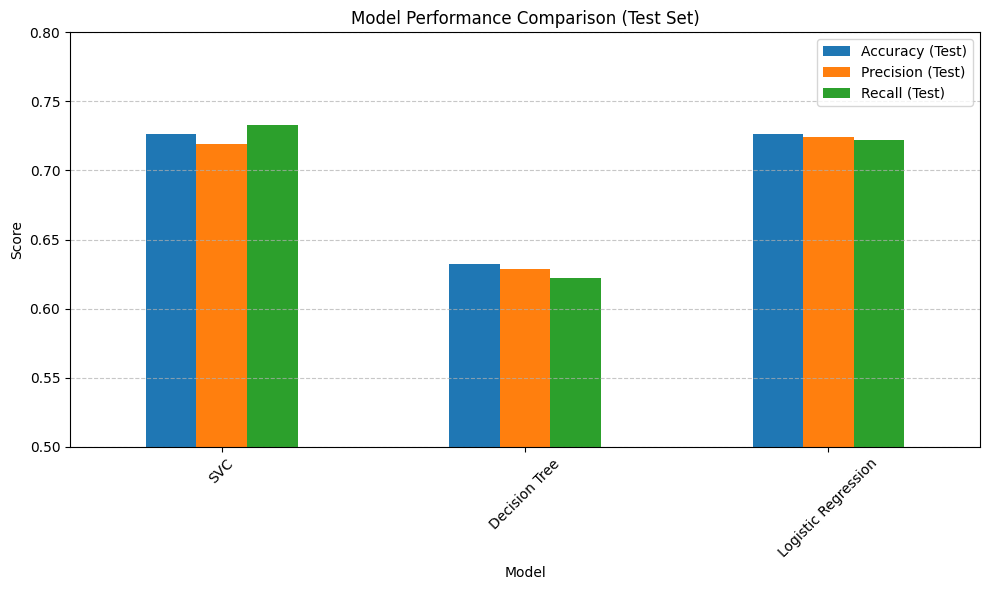

In [86]:
# Create a DataFrame to store the performance metrics of all models
model_performance = pd.DataFrame({
    'Model': ['SVC', 'Decision Tree', 'Logistic Regression'],
    'Accuracy (Test)': [
        accuracy_score(y_test, y_pred_svm_optimal_cutoff_test),
        accuracy_score(y_test, y_pred_dt_optimal_cutoff_test),
        accuracy_score(y_test, y_pred_logreg_optimal_cutoff_test)
    ],
    'Precision (Test)': [
        precision_score(y_test, y_pred_svm_optimal_cutoff_test),
        precision_score(y_test, y_pred_dt_optimal_cutoff_test),
        precision_score(y_test, y_pred_logreg_optimal_cutoff_test)
    ],
    'Recall (Test)': [
        recall_score(y_test, y_pred_svm_optimal_cutoff_test),
        recall_score(y_test, y_pred_dt_optimal_cutoff_test),
        recall_score(y_test, y_pred_logreg_optimal_cutoff_test)
    ]
})

# Display the performance comparison
print("\n--- Model Performance Comparison (Test Set with Optimal Cutoff) ---")
display(model_performance.round(4))

# You can also visualize this comparison
model_performance.set_index('Model').plot(kind='bar', figsize=(10, 6))
plt.title('Model Performance Comparison (Test Set)')
plt.ylabel('Score')
plt.ylim(0.5, 0.8) # Adjust y-axis limit for better visualization
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### **6.3 Hyperparameter Tuning**

<font color = red>[8 Marks]</font>

Enhance the performance of the decision tree model by systematically exploring and selecting optimal hyperparameter values using Grid Search.

#### **6.3.1** Use grid search to find the best hyperparameter values <font color = red>[4 Marks]</font>

Perform hyperparameter tuning to see if the performance of the decision tree model can be improved. Tune for **at least 4 decision tree hyperparameters**.

In [87]:
# Define the parameter grid for the decision tree
param_grid = {
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

# Initialize GridSearchCV
grid_search_dt = GridSearchCV(estimator=DecisionTreeClassifier(random_state=42),
                            param_grid=param_grid,
                            cv=5, # Using 5-fold cross-validation
                            scoring='recall', # Prioritize recall as per problem statement
                            verbose=1,
                            n_jobs=-1) # Use all available cores

# Fit GridSearchCV to the training data
grid_search_dt.fit(X_train, y_train)

# Print the best hyperparameters
print(f"Best hyperparameters for Decision Tree: {grid_search_dt.best_params_}")
print(f"Best recall score: {grid_search_dt.best_score_:.4f}")

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best hyperparameters for Decision Tree: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best recall score: 0.6963


#### **6.3.2** Build a decision tree model based on hyperparameter tuning results <font color = red>[2 Marks]</font>


In [88]:
# Use the best estimator from grid search
dt_tuned_model = grid_search_dt.best_estimator_

print("Tuned Decision Tree model created successfully:")
print(dt_tuned_model)

Tuned Decision Tree model created successfully:
DecisionTreeClassifier(criterion='entropy', max_depth=10, random_state=42)


#### **6.3.3** Using the tuned model, make predictions and evaluate <font color="red">[2 Mark]</font>

Use the tuned model to directly predict the labels and evaluate the performance on both training and testing sets to check overfitting / underfitting.

In [89]:
# Evaluate the tuned model performance on training set
y_pred_dt_tuned_train = dt_tuned_model.predict(X_train)

print("--- Performance on Training Set (Tuned Decision Tree) ---")
print("Accuracy:", accuracy_score(y_train, y_pred_dt_tuned_train))
print("Precision:", precision_score(y_train, y_pred_dt_tuned_train))
print("Recall:", recall_score(y_train, y_pred_dt_tuned_train))
print("\nClassification Report:\n", classification_report(y_train, y_pred_dt_tuned_train))
print("\nConfusion Matrix:\n", confusion_matrix(y_train, y_pred_dt_tuned_train))

--- Performance on Training Set (Tuned Decision Tree) ---
Accuracy: 0.7461150689497146
Precision: 0.7551227250694047
Recall: 0.7209997054739765

Classification Report:
               precision    recall  f1-score   support

           0       0.74      0.77      0.75     24239
           1       0.76      0.72      0.74     23767

    accuracy                           0.75     48006
   macro avg       0.75      0.75      0.75     48006
weighted avg       0.75      0.75      0.75     48006


Confusion Matrix:
 [[18682  5557]
 [ 6631 17136]]


In [90]:
# Evaluate the tuned model performance on test set
y_pred_dt_tuned_test = dt_tuned_model.predict(X_test)

print("--- Performance on Test Set (Tuned Decision Tree) ---")
print("Accuracy:", accuracy_score(y_test, y_pred_dt_tuned_test))
print("Precision:", precision_score(y_test, y_pred_dt_tuned_test))
print("Recall:", recall_score(y_test, y_pred_dt_tuned_test))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt_tuned_test))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dt_tuned_test))

--- Performance on Test Set (Tuned Decision Tree) ---
Accuracy: 0.7216389617964422
Precision: 0.725516119190481
Recall: 0.7020271600078725

Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.74      0.73     10412
           1       0.73      0.70      0.71     10162

    accuracy                           0.72     20574
   macro avg       0.72      0.72      0.72     20574
weighted avg       0.72      0.72      0.72     20574


Confusion Matrix:
 [[7713 2699]
 [3028 7134]]


#### **6.3.3.1** Get Probability Estimates for Tuned Decision Tree Model

Generate probability estimates for the tuned Decision Tree model on both the training and testing datasets.

In [91]:
# Get probability estimates for the tuned Decision Tree model on the test set
y_pred_proba_dt_tuned_test = dt_tuned_model.predict_proba(X_test)[:, 1]
print("Probability estimates for the positive class on the test set (Tuned Decision Tree) have been generated.")
print("First 5 probability estimates:", y_pred_proba_dt_tuned_test[:5])

# Get probability estimates for the tuned Decision Tree model on the training set
y_pred_proba_dt_tuned_train = dt_tuned_model.predict_proba(X_train)[:, 1]
print("\nProbability estimates for the positive class on the training set (Tuned Decision Tree) have been generated.")
print("First 5 probability estimates:", y_pred_proba_dt_tuned_train[:5])

Probability estimates for the positive class on the test set (Tuned Decision Tree) have been generated.
First 5 probability estimates: [0.41439689 0.28240406 0.14908257 0.47448276 0.60107817]

Probability estimates for the positive class on the training set (Tuned Decision Tree) have been generated.
First 5 probability estimates: [0.38278146 0.24897401 0.6391129  0.53381295 0.38278146]


#### **6.3.3.2** Plot ROC Curve for Tuned Decision Tree Model

Plot the Receiver Operating Characteristic (ROC) curve to visualize the trade-off between true positive rate and false positive rate across different classification thresholds for the tuned model.

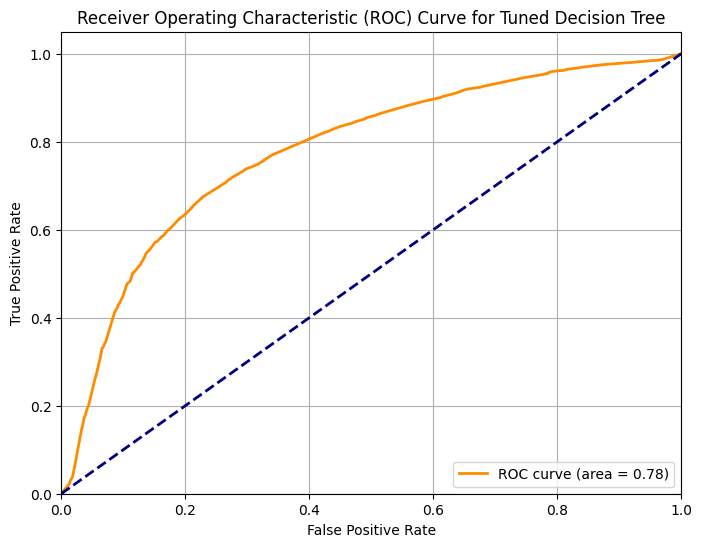

In [92]:
fpr_dt_tuned, tpr_dt_tuned, thresholds_dt_tuned = roc_curve(y_test, y_pred_proba_dt_tuned_test)
roc_auc_dt_tuned = roc_auc_score(y_test, y_pred_proba_dt_tuned_test)

plt.figure(figsize=(8, 6))
plt.plot(fpr_dt_tuned, tpr_dt_tuned, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_dt_tuned:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Tuned Decision Tree')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

#### **6.3.3.3** Plot Accuracy, Sensitivity, and Specificity at Different Probability Cutoffs for Tuned Decision Tree Model

Analyze the impact of different probability cutoffs on the model's accuracy, sensitivity, and specificity to determine an optimal threshold.

DataFrame created showing accuracy, sensitivity, and specificity at different cutoffs for Tuned Decision Tree.


,Threshold,Accuracy,Sensitivity,Specificity
0,inf,0.506076,0.000000,1.000000
1,1.000000,0.510693,0.022338,0.987322
2,0.979592,0.510888,0.023027,0.987034
3,0.973684,0.511422,0.024700,0.986458
4,0.956522,0.511374,0.024995,0.986074


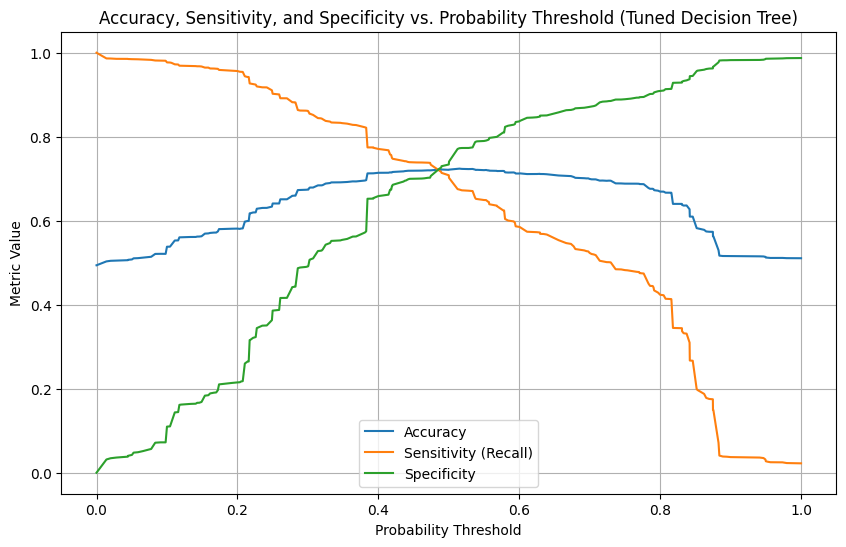

In [93]:
metrics_dt_tuned = []
for threshold in thresholds_dt_tuned:
    y_pred_dt_tuned_threshold = (y_pred_proba_dt_tuned_test >= threshold).astype(int)

    acc_dt_tuned = accuracy_score(y_test, y_pred_dt_tuned_threshold)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_dt_tuned_threshold).ravel()
    sens_dt_tuned = tp / (tp + fn) if (tp + fn) != 0 else 0
    spec_dt_tuned = tn / (tn + fp) if (tn + fp) != 0 else 0

    metrics_dt_tuned.append({'Threshold': threshold, 'Accuracy': acc_dt_tuned, 'Sensitivity': sens_dt_tuned, 'Specificity': spec_dt_tuned})

metrics_df_dt_tuned = pd.DataFrame(metrics_dt_tuned)
print("DataFrame created showing accuracy, sensitivity, and specificity at different cutoffs for Tuned Decision Tree.")
display(metrics_df_dt_tuned.head())

plt.figure(figsize=(10, 6))
plt.plot(metrics_df_dt_tuned['Threshold'], metrics_df_dt_tuned['Accuracy'], label='Accuracy')
plt.plot(metrics_df_dt_tuned['Threshold'], metrics_df_dt_tuned['Sensitivity'], label='Sensitivity (Recall)')
plt.plot(metrics_df_dt_tuned['Threshold'], metrics_df_dt_tuned['Specificity'], label='Specificity')
plt.xlabel('Probability Threshold')
plt.ylabel('Metric Value')
plt.title('Accuracy, Sensitivity, and Specificity vs. Probability Threshold (Tuned Decision Tree)')
plt.legend()
plt.grid(True)
plt.show()

#### **6.3.3.4** Assign Classes Based on Optimal Cutoff and Evaluate Tuned Decision Tree Model

Determine the optimal cutoff using Youden's J statistic and then evaluate the tuned model's performance on both training and testing sets with this optimal cutoff to check for overfitting.

In [94]:
# Make final prediction based on the optimal cutoff using Youden's J statistic
metrics_df_dt_tuned['Youden_J'] = metrics_df_dt_tuned['Sensitivity'] + metrics_df_dt_tuned['Specificity'] - 1
optimal_row_dt_tuned = metrics_df_dt_tuned.loc[metrics_df_dt_tuned['Youden_J'].idxmax()]
optimal_threshold_dt_tuned = optimal_row_dt_tuned['Threshold']

print(f"Optimal threshold (maximizing Youden's J) for Tuned Decision Tree: {optimal_threshold_dt_tuned:.4f}")

# Make predictions on the test set using the optimal cutoff
y_pred_dt_tuned_optimal_cutoff_test = (y_pred_proba_dt_tuned_test >= optimal_threshold_dt_tuned).astype(int)

# Make predictions on the training set using the optimal cutoff
y_pred_dt_tuned_optimal_cutoff_train = (y_pred_proba_dt_tuned_train >= optimal_threshold_dt_tuned).astype(int)

print("Predictions made on test and train sets using the optimal cutoff for Tuned Decision Tree.")

# Evaluate the model performance for test and train
print("\n--- Performance on Test Set (Tuned Decision Tree, Optimal Cutoff) ---")
print("Accuracy:", accuracy_score(y_test, y_pred_dt_tuned_optimal_cutoff_test))
print("Precision:", precision_score(y_test, y_pred_dt_tuned_optimal_cutoff_test))
print("Recall:", recall_score(y_test, y_pred_dt_tuned_optimal_cutoff_test))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt_tuned_optimal_cutoff_test))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dt_tuned_optimal_cutoff_test))

print("\n--- Performance on Training Set (Tuned Decision Tree, Optimal Cutoff) ---")
print("Accuracy:", accuracy_score(y_train, y_pred_dt_tuned_optimal_cutoff_train))
print("Precision:", precision_score(y_train, y_pred_dt_tuned_optimal_cutoff_train))
print("Recall:", recall_score(y_train, y_pred_dt_tuned_optimal_cutoff_train))
print("\nClassification Report:\n", classification_report(y_train, y_pred_dt_tuned_optimal_cutoff_train))
print("\nConfusion Matrix:\n", confusion_matrix(y_train, y_pred_dt_tuned_optimal_cutoff_train))

Optimal threshold (maximizing Youden's J) for Tuned Decision Tree: 0.5152
Predictions made on test and train sets using the optimal cutoff for Tuned Decision Tree.

--- Performance on Test Set (Tuned Decision Tree, Optimal Cutoff) ---
Accuracy: 0.7240206085350442
Precision: 0.743219787372532
Recall: 0.6741783113560322

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.77      0.74     10412
           1       0.74      0.67      0.71     10162

    accuracy                           0.72     20574
   macro avg       0.73      0.72      0.72     20574
weighted avg       0.73      0.72      0.72     20574


Confusion Matrix:
 [[8045 2367]
 [3311 6851]]

--- Performance on Training Set (Tuned Decision Tree, Optimal Cutoff) ---
Accuracy: 0.7460525767612382
Precision: 0.7728129713423831
Recall: 0.689864097277738

Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.80      0.

#### **6.3.3.5** Plot Precision-Recall Curve for Tuned Decision Tree Model

Visualize the precision-recall trade-off for the tuned Decision Tree model.

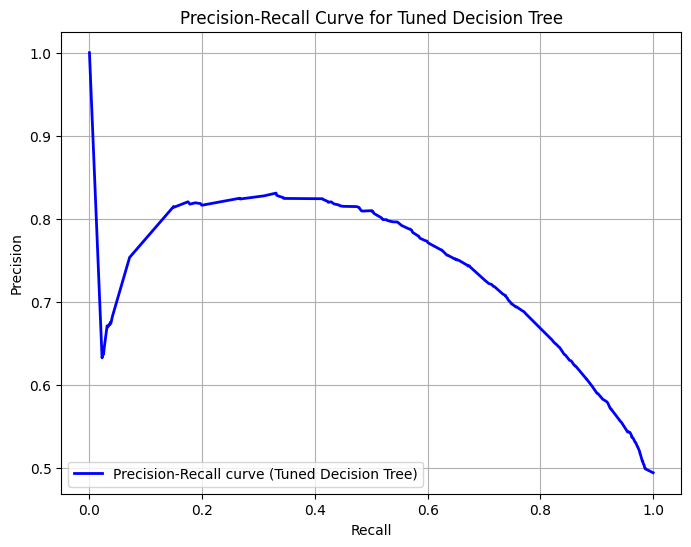

In [95]:
precision_dt_tuned, recall_dt_tuned, _ = precision_recall_curve(y_test, y_pred_proba_dt_tuned_test)

plt.figure(figsize=(8, 6))
plt.plot(recall_dt_tuned, precision_dt_tuned, color='blue', lw=2, label='Precision-Recall curve (Tuned Decision Tree)')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for Tuned Decision Tree')
plt.grid(True)
plt.legend(loc='lower left')
plt.show()

#### **6.3.4** Optionally, use grid search to find the best hyperparameter values for SVM

Try to fine-tune SVM hyperparameters like kernels, `C` and `gamma`.

#### **6.3.4** Optionally, use grid search to find the best hyperparameter values for SVM

Try to fine-tune SVM hyperparameters like kernels, `C` and `gamma`.

In [ ]:
# Define the parameter grid for SVM
param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'kernel': ['linear', 'rbf'] # Explore linear and RBF kernels
}

# Initialize GridSearchCV for SVM
grid_search_svm = GridSearchCV(estimator=SVC(probability=True, random_state=42),
                             param_grid=param_grid_svm,
                             cv=5, # Using 5-fold cross-validation
                             scoring='recall', # Prioritize recall
                             verbose=1,
                             n_jobs=-1) # Use all available cores

# Fit GridSearchCV to the training data
grid_search_svm.fit(X_train, y_train)

# Print the best hyperparameters and score
print(f"Best hyperparameters for SVM: {grid_search_svm.best_params_}")
print(f"Best recall score for SVM: {grid_search_svm.best_score_:.4f}")

# Get the best estimator
svm_tuned_model = grid_search_svm.best_estimator_
print("\nTuned SVM model created successfully:")
print(svm_tuned_model)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


#### **6.3.4.1** Get Probability Estimates for Tuned SVM Model

Generate probability estimates for the tuned SVM model on both the training and testing datasets.

In [ ]:
# Get probability estimates for the tuned SVM model on the test set
y_pred_proba_svm_tuned_test = svm_tuned_model.predict_proba(X_test)[:, 1]
print("Probability estimates for the positive class on the test set (Tuned SVM) have been generated.")
print("First 5 probability estimates:", y_pred_proba_svm_tuned_test[:5])

# Get probability estimates for the tuned SVM model on the training set
y_pred_proba_svm_tuned_train = svm_tuned_model.predict_proba(X_train)[:, 1]
print("\nProbability estimates for the positive class on the training set (Tuned SVM) have been generated.")
print("First 5 probability estimates:", y_pred_proba_svm_tuned_train[:5])

#### **6.3.4.2** Plot ROC Curve for Tuned SVM Model

Plot the Receiver Operating Characteristic (ROC) curve to visualize the trade-off between true positive rate and false positive rate across different classification thresholds for the tuned model.

In [ ]:
fpr_svm_tuned, tpr_svm_tuned, thresholds_svm_tuned = roc_curve(y_test, y_pred_proba_svm_tuned_test)
roc_auc_svm_tuned = roc_auc_score(y_test, y_pred_proba_svm_tuned_test)

plt.figure(figsize=(8, 6))
plt.plot(fpr_svm_tuned, tpr_svm_tuned, color='darkgreen', lw=2, label=f'ROC curve (area = {roc_auc_svm_tuned:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Tuned SVM')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

#### **6.3.4.3** Plot Accuracy, Sensitivity, and Specificity at Different Probability Cutoffs for Tuned SVM Model

Analyze the impact of different probability cutoffs on the model's accuracy, sensitivity, and specificity to determine an optimal threshold.

In [ ]:
metrics_svm_tuned = []
for threshold in thresholds_svm_tuned:
    y_pred_svm_tuned_threshold = (y_pred_proba_svm_tuned_test >= threshold).astype(int)

    acc_svm_tuned = accuracy_score(y_test, y_pred_svm_tuned_threshold)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_svm_tuned_threshold).ravel()
    sens_svm_tuned = tp / (tp + fn) if (tp + fn) != 0 else 0
    spec_svm_tuned = tn / (tn + fp) if (tn + fp) != 0 else 0

    metrics_svm_tuned.append({'Threshold': threshold, 'Accuracy': acc_svm_tuned, 'Sensitivity': sens_svm_tuned, 'Specificity': spec_svm_tuned})

metrics_df_svm_tuned = pd.DataFrame(metrics_svm_tuned)
print("DataFrame created showing accuracy, sensitivity, and specificity at different cutoffs for Tuned SVM.")
display(metrics_df_svm_tuned.head())

plt.figure(figsize=(10, 6))
plt.plot(metrics_df_svm_tuned['Threshold'], metrics_df_svm_tuned['Accuracy'], label='Accuracy')
plt.plot(metrics_df_svm_tuned['Threshold'], metrics_df_svm_tuned['Sensitivity'], label='Sensitivity (Recall)')
plt.plot(metrics_df_svm_tuned['Threshold'], metrics_df_svm_tuned['Specificity'], label='Specificity')
plt.xlabel('Probability Threshold')
plt.ylabel('Metric Value')
plt.title('Accuracy, Sensitivity, and Specificity vs. Probability Threshold (Tuned SVM)')
plt.legend()
plt.grid(True)
plt.show()

#### **6.3.4.4** Assign Classes Based on Optimal Cutoff and Evaluate Tuned SVM Model

Determine the optimal cutoff using Youden's J statistic and then evaluate the tuned model's performance on both training and testing sets with this optimal cutoff to check for overfitting.

In [ ]:
# Make final prediction based on the optimal cutoff using Youden's J statistic
metrics_df_svm_tuned['Youden_J'] = metrics_df_svm_tuned['Sensitivity'] + metrics_df_svm_tuned['Specificity'] - 1
optimal_row_svm_tuned = metrics_df_svm_tuned.loc[metrics_df_svm_tuned['Youden_J'].idxmax()]
optimal_threshold_svm_tuned = optimal_row_svm_tuned['Threshold']

print(f"Optimal threshold (maximizing Youden's J) for Tuned SVM: {optimal_threshold_svm_tuned:.4f}")

# Make predictions on the test set using the optimal cutoff
y_pred_svm_tuned_optimal_cutoff_test = (y_pred_proba_svm_tuned_test >= optimal_threshold_svm_tuned).astype(int)

# Make predictions on the training set using the optimal cutoff
y_pred_svm_tuned_optimal_cutoff_train = (y_pred_proba_svm_tuned_train >= optimal_threshold_svm_tuned).astype(int)

print("Predictions made on test and train sets using the optimal cutoff for Tuned SVM.")

# Evaluate the model performance for test and train
print("\n--- Performance on Test Set (Tuned SVM, Optimal Cutoff) ---")
print("Accuracy:", accuracy_score(y_test, y_pred_svm_tuned_optimal_cutoff_test))
print("Precision:", precision_score(y_test, y_pred_svm_tuned_optimal_cutoff_test))
print("Recall:", recall_score(y_test, y_pred_svm_tuned_optimal_cutoff_test))
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm_tuned_optimal_cutoff_test))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_svm_tuned_optimal_cutoff_test))

print("\n--- Performance on Training Set (Tuned SVM, Optimal Cutoff) ---")
print("Accuracy:", accuracy_score(y_train, y_pred_svm_tuned_optimal_cutoff_train))
print("Precision:", precision_score(y_train, y_pred_svm_tuned_optimal_cutoff_train))
print("Recall:", recall_score(y_train, y_pred_svm_tuned_optimal_cutoff_train))
print("\nClassification Report:\n", classification_report(y_train, y_pred_svm_tuned_optimal_cutoff_train))
print("\nConfusion Matrix:\n", confusion_matrix(y_train, y_pred_svm_tuned_optimal_cutoff_train))

#### **6.3.4.5** Plot Precision-Recall Curve for Tuned SVM Model

Visualize the precision-recall trade-off for the tuned SVM model.

In [ ]:
precision_svm_tuned, recall_svm_tuned, _ = precision_recall_curve(y_test, y_pred_proba_svm_tuned_test)

plt.figure(figsize=(8, 6))
plt.plot(recall_svm_tuned, precision_svm_tuned, color='darkgreen', lw=2, label='Precision-Recall curve (Tuned SVM)')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for Tuned SVM')
plt.grid(True)
plt.legend(loc='lower left')
plt.show()

You can also check the performance of SVM with `RBF` kernel

Tune your third candidate model, if taken

## **7. Final Model Evaluation and Selection**

<font color = red>[2 Marks]</font>

Use you final models to make predictions on the test data. Evaluate the models, create model cards, and finally write your conclusive findings, results, and insights from the steps performed.

Include these in your report as well.

### **7.1 Evaluate the final models**

<font color = red>[2 Marks]</font>

Make predictions using the tuned models and selected features to check the training and testing performances and create model cards for both.

#### **7.1.1** Make final predictions and evaluate <font color="red">[2 Marks]</font>

Evaluate the performance of your final candidates

In [ ]:
# Make predictions on test and train sets using all candidate models
# use the chosen optimal cutoff


### **7.2 Conclusion**

#### **7.2.1** Model Cards

Create model cards for all your candidate models. Include this in your report.

Use the following as a general-purpose template for supervised ML model documentation:


**Model Card: [Model name]**

**Model overview:**
Brief description of the model, its purpose, and context.

**Intended use:**

* Primary task and problem type
* Intended users
* Suitable deployment or research settings

**Data and features:**

* Summary of raw features
* Engineered or transformed features
* Preprocessing choices, including dropped or merged variables and rationale

**Model configuration:**

* Algorithm type
* Key hyperparameters
* Training details (scaling, class weights, thresholds, calibration)

**Performance:**

* Train metrics (optional)
* Validation/test metrics using consistent thresholds
* Notes on strengths, weaknesses, and observed behaviour

**Limitations and considerations:**

* Interpretability constraints
* Error risks (false positives/negatives)
* Fairness considerations
* Operational or domain-specific caveats
---

#### **7.2.2** Conclusions and Outcomes

Try to answer the following questions in your answer. Include this in the report.

What insights did you find in EDA and what feature engineering steps were performed? Describe your choice of models and the performance of baseline models. Did you find overfitting? How was it handled and what was the result of tuning? Was the data sufficent? Is a linear model sufficient? What model did you choose? Explain the final outcomes.